# Multi-Asset Systematic Allocation
## Phase 0: Trend Signals and Volatility-Scaled Portfolio Construction

### Research Question

Does a simple trend signal improve a diversified multi-asset portfolio after transaction costs, and how much of the result is attributable to the trend signal versus volatility-based portfolio sizing?

### Primary Hypothesis

Assets with positive medium-term trends may exhibit return persistence. A simple trend filter combined with volatility-based position sizing may improve the risk-adjusted performance of a diversified multi-asset portfolio relative to static allocation.

### Null Hypothesis

Any apparent improvement may disappear out of sample or after transaction costs.

---

### Pre-Specified Phase 0 Design

- Universe: 8 liquid ETFs across multiple asset classes
    - SPY: US Equity
    - EFA: Developed Markets ex-US Equity
    - EEM: Emerging Markets Equity
    - IEF: US Treasury Bonds
    - LQD: Investment Grade Corporate Bonds
    - GLD: Gold
    - VNQ: US Real Estate
    - DBC: Broad Commodities
- Data frequency: Daily market data
- Portfolio rebalancing: Monthly
- Primary trend signal: 12-month total return > 0
- Volatility estimate: 63-trading-day realized volatility
- Portfolio: Long-only
- Transaction cost assumption: 10 bps per unit of risky-asset notional traded
- Raw data start: 2007-01-01
- In-Sample evaluation period: through 2018-12-31
- Out-of-Sample evaluation period: from 2019-01-01 through the last available observation
- Effective strategy results begin only after sufficient lookback data are available
- Primary benchmark: Monthly rebalanced equal-weight portfolio
- Secondary benchmark: SPY Buy & Hold
- No machine learning in Phase 0
- No parameter optimization based on backtest results

---

### Portfolio Ablation

Four portfolio variants will be evaluated.

#### 1. Equal Weight

Each of the eight risky assets receives a target weight of:

w_i = 1 / N

where N = 8.

The portfolio is rebalanced monthly back to equal weights.

#### 2. Inverse Volatility

All eight risky assets remain eligible.

Raw weights are proportional to the inverse of each asset's estimated volatility:

raw_weight_i = 1 / volatility_i

Weights are normalized so that total risky-asset exposure equals 100%:

w_i = raw_weight_i / sum(raw_weight_j)

#### 3. Trend + Equal Weight

Each asset receives its original equal-weight allocation only when its 12-month trend signal is positive:

w_i = signal_i × (1 / N)

where:

signal_i = 1 if the 12-month return is positive  
signal_i = 0 otherwise

Inactive assets receive zero weight.

The unused allocation is held in cash and is not redistributed to the remaining active assets.

#### 4. Trend + Inverse Volatility

First, the standard inverse-volatility weights are calculated across the full eight-asset universe.

The trend filter is then applied:

w_i = signal_i × inverse_vol_weight_i

Assets with non-positive trend receive zero weight.

Their removed allocation is held in cash and is not redistributed to the remaining active assets.

This design allows the contribution of the trend filter to be evaluated separately from the contribution of volatility-based portfolio sizing.

---

### Cash Treatment

Cash represents capital not allocated to risky assets in the trend-based portfolios.

Cash weight is:

cash_weight = 1 - sum(risky_asset_weights)

Cash earns a 0% return in Phase 0.

No leverage is used.

---

### Signal Timing

All signals and volatility estimates use only information available at the portfolio formation date.

Information observed through month-end t is used to determine target portfolio weights at month-end t.

Those weights are applied only to returns earned during month t+1.

No future price, return, volatility, or signal information is used in portfolio formation.

---

### Turnover and Transaction Costs

Portfolio turnover is based on the risky-asset notional actually traded at each monthly rebalance.

Before each rebalance, the previous target weights are allowed to drift according to realized asset returns.

Turnover is then calculated as the total absolute change required to move from the pre-rebalance risky-asset weights to the new target risky-asset weights:

Turnover_t = sum(|target_weight_i,t - pre_rebalance_weight_i,t|)

Cash itself does not incur a transaction cost, but purchases and sales of risky assets used to move capital into or out of cash do.

Transaction cost is:

Cost_t = Turnover_t × 0.001

The same transaction-cost methodology is applied consistently across the four portfolio strategies.

---

### Research Discipline

The following primary design choices are fixed before examining strategy performance:

- 8-ETF universe
- 12-month trend signal
- 63-trading-day volatility estimate
- Monthly rebalancing
- 10 bps transaction cost assumption
- 2019-01-01 OOS start date
- 0% cash return
- Four pre-specified portfolio variants

Sensitivity analysis may later test nearby assumptions, but the primary specification will not be replaced based on which alternative produces the highest historical performance.

In [1]:
!pip install -q yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", None)

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("yfinance version:", yf.__version__)

pandas version: 2.2.2
numpy version: 2.0.2
yfinance version: 0.2.66


In [3]:
# ==========================================
# Phase 0 Research Configuration
# ==========================================

# Pre-specified multi-asset ETF universe
TICKERS = [
    "SPY",  # US Equity
    "EFA",  # Developed Markets ex-US Equity
    "EEM",  # Emerging Markets Equity
    "IEF",  # US Treasury Bonds
    "LQD",  # Investment Grade Corporate Bonds
    "GLD",  # Gold
    "VNQ",  # US Real Estate
    "DBC",  # Broad Commodities
]

# Data period
START_DATE = "2007-01-01"
END_DATE = "2026-08-13"

# Signal and risk estimation
TREND_LOOKBACK_MONTHS = 12
VOL_LOOKBACK_DAYS = 63

# Portfolio implementation
REBALANCE_FREQUENCY = "monthly"
TRANSACTION_COST = 0.001  # 10 basis points
CASH_RETURN = 0.0

# Evaluation split
OOS_START = "2019-01-01"

# Universe size
N_ASSETS = len(TICKERS)

print("=== PHASE 0 CONFIGURATION ===")
print("Universe:", TICKERS)
print("Number of risky assets:", N_ASSETS)
print("Raw data period:", START_DATE, "to", END_DATE)
print("Trend lookback:", TREND_LOOKBACK_MONTHS, "months")
print("Volatility lookback:", VOL_LOOKBACK_DAYS, "trading days")
print("Rebalancing:", REBALANCE_FREQUENCY)
print("Transaction cost:", TRANSACTION_COST)
print("Cash return:", CASH_RETURN)
print("OOS start:", OOS_START)

=== PHASE 0 CONFIGURATION ===
Universe: ['SPY', 'EFA', 'EEM', 'IEF', 'LQD', 'GLD', 'VNQ', 'DBC']
Number of risky assets: 8
Raw data period: 2007-01-01 to 2026-08-13
Trend lookback: 12 months
Volatility lookback: 63 trading days
Rebalancing: monthly
Transaction cost: 0.001
Cash return: 0.0
OOS start: 2019-01-01


In [4]:
# ==========================================
# Step 4: Download Daily Market Data
# ==========================================

raw = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False,
    group_by="column",
    multi_level_index=True
)

print("Download completed.")
print("Raw data shape:", raw.shape)

display(raw.head())

Download completed.
Raw data shape: (4933, 40)


Price           Close                                                         \
Ticker            DBC        EEM        EFA        GLD        IEF        LQD   
Date                                                                           
2007-01-03  19.330030  25.692616  41.088043  62.279999  50.140358  49.091709   
2007-01-04  18.826479  25.337820  40.970669  61.650002  50.322292  49.460670   
2007-01-05  18.761501  24.596996  40.355824  60.169998  50.158550  49.428383   
2007-01-08  18.858959  24.775515  40.411720  60.480000  50.194965  49.414547   
2007-01-09  18.696524  24.222113  40.450836  60.849998  50.182823  49.423737   

Price                                  High                                   \
Ticker            SPY        VNQ        DBC        EEM        EFA        GLD   
Date                                                                           
2007-01-03  98.869507  34.298180  19.768612  25.976006  41.401051  64.019997   
2007-01-04  99.079292  34.342667  19.248816  25.500716  41.065688  62.500000   
2007-01-05  98.289024  33.706684  18.964548  25.137002  40.685603  60.779999   
2007-01-08  98.743599  33.755611  19.135103  24.867005  40.506740  60.540001   
2007-01-09  98.659698  34.182552  18.793985  24.623768  40.618517  61.090000   

Price                                                         Low             \
Ticker            IEF        LQD        SPY        VNQ        DBC        EEM   
Date                                                                           
2007-01-03  50.213132  49.437588  99.911567  34.560573  19.232569  25.491788   
2007-01-04  50.322292  49.483730  99.345055  34.360457  18.729016  25.177159   
2007-01-05  50.219193  49.437605  98.890480  34.289290  18.558455  24.594767   
2007-01-08  50.194965  49.446829  98.897460  33.800085  18.672157  24.603696   
2007-01-09  50.231339  49.451409  99.030362  34.227025  18.257942  24.088227   

Price                                                                         \
Ticker            EFA        GLD        IEF        LQD        SPY        VNQ   
Date                                                                           
2007-01-03  40.959484  62.000000  50.019072  48.971807  98.310022  33.977968   
2007-01-04  40.814161  61.520000  50.170683  49.225472  98.337965  34.080269   
2007-01-05  40.299930  59.660000  50.043325  49.285421  98.177134  33.688894   
2007-01-08  40.305519  59.849998  50.128261  49.331536  98.086192  33.546584   
2007-01-09  40.260793  60.060001  50.152499  49.382233  98.191113  33.680000   

Price            Open                                                         \
Ticker            DBC        EEM        EFA        GLD        IEF        LQD   
Date                                                                           
2007-01-03  19.711759  25.884518  41.339567  63.580002  50.158550  49.414531   
2007-01-04  19.126987  25.494020  40.976255  62.070000  50.231326  49.225472   
2007-01-05  18.720891  25.081217  40.685603  60.750000  50.079715  49.345372   
2007-01-08  19.086372  24.742044  40.506740  60.380001  50.164646  49.331536   
2007-01-09  18.396014  24.590297  40.607340  60.139999  50.225274  49.419127   

Price                               Volume                                  \
Ticker            SPY        VNQ       DBC         EEM       EFA       GLD   
Date                                                                         
2007-01-03  99.484953  34.396019  746800.0  38546100.0  12081400   8061900   
2007-01-04  98.771569  34.347115  428900.0  26830200.0   8674000   4858600   
2007-01-05  98.841530  34.289290  369800.0  33141600.0   8961600  12500100   
2007-01-08  98.484837  33.800085  275200.0  23326500.0   6584100   3478700   
2007-01-09  98.827540  33.680000  675600.0  43958400.0   8505700   4170400   

Price                                               
Ticker            IEF      LQD       SPY       VNQ  
Date                                                
2007-01-03 

In [5]:
# ==========================================
# Extract Adjusted Close Prices
# ==========================================

prices = raw["Close"].copy()

# Keep the pre-specified ETF order
prices = prices.reindex(columns=TICKERS)

print("Price data shape:", prices.shape)
print("Columns:", prices.columns.tolist())

display(prices.head())

Price data shape: (4933, 8)
Columns: ['SPY', 'EFA', 'EEM', 'IEF', 'LQD', 'GLD', 'VNQ', 'DBC']


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-03,98.869507,41.088043,25.692616,50.140358,49.091709,62.279999,34.298180,19.330030
2007-01-04,99.079292,40.970669,25.337820,50.322292,49.460670,61.650002,34.342667,18.826479
2007-01-05,98.289024,40.355824,24.596996,50.158550,49.428383,60.169998,33.706684,18.761501
2007-01-08,98.743599,40.411720,24.775515,50.194965,49.414547,60.480000,33.755611,18.858959
2007-01-09,98.659698,40.450836,24.222113,50.182823,49.423737,60.849998,34.182552,18.696524


In [6]:
# ==========================================
# Step 5: Data Quality Checks
# ==========================================

print("=== 1. DATA SHAPE ===")
print(prices.shape)

print("\n=== 2. FIRST 5 OBSERVATIONS ===")
display(prices.head())

print("\n=== 3. LAST 5 OBSERVATIONS ===")
display(prices.tail())

print("\n=== 4. FIRST VALID DATE BY ASSET ===")
first_valid_dates = prices.apply(lambda x: x.first_valid_index())
display(first_valid_dates)

print("\n=== 5. LAST VALID DATE BY ASSET ===")
last_valid_dates = prices.apply(lambda x: x.last_valid_index())
display(last_valid_dates)

print("\n=== 6. MISSING VALUES BY ASSET ===")
missing_counts = prices.isna().sum()
display(missing_counts)

print("\n=== 7. NUMBER OF OBSERVATIONS BY ASSET ===")
observation_counts = prices.count()
display(observation_counts)

print("\n=== 8. PRICE SUMMARY ===")
display(prices.describe().T)

=== 1. DATA SHAPE ===
(4933, 8)

=== 2. FIRST 5 OBSERVATIONS ===


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-03,98.869507,41.088043,25.692616,50.140358,49.091709,62.279999,34.298180,19.330030
2007-01-04,99.079292,40.970669,25.337820,50.322292,49.460670,61.650002,34.342667,18.826479
2007-01-05,98.289024,40.355824,24.596996,50.158550,49.428383,60.169998,33.706684,18.761501
2007-01-08,98.743599,40.411720,24.775515,50.194965,49.414547,60.480000,33.755611,18.858959
2007-01-09,98.659698,40.450836,24.222113,50.182823,49.423737,60.849998,34.182552,18.696524



=== 3. LAST 5 OBSERVATIONS ===


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-08-06,768.559998,107.360001,65.019997,92.949997,106.360001,389.670013,98.040001,28.860001
2026-08-07,773.260010,108.550003,65.639999,93.169998,106.550003,398.470001,98.430000,28.910000
2026-08-10,773.030029,108.010002,65.169998,92.760002,105.959999,402.540009,97.110001,29.930000
2026-08-11,770.559998,108.089996,65.430000,92.870003,105.989998,400.959991,96.379997,29.969999
2026-08-12,772.489990,108.500000,66.459999,92.959999,106.120003,404.920013,97.309998,30.110001



=== 4. FIRST VALID DATE BY ASSET ===


...

,0
Ticker,
SPY,0
EFA,0
EEM,1
IEF,1
LQD,0
GLD,0
VNQ,1
DBC,3



=== 7. NUMBER OF OBSERVATIONS BY ASSET ===


,0
Ticker,
SPY,4933
EFA,4933
EEM,4932
IEF,4932
LQD,4933
GLD,4933
VNQ,4932
DBC,4930



=== 8. PRICE SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,4933.0,253.511432,174.924159,49.680553,105.655174,185.661209,375.575958,773.260010
EFA,4933.0,51.187679,17.088402,18.750858,39.597736,46.741817,60.768116,108.550003
EEM,4932.0,34.789884,8.474466,12.522425,29.700054,33.408104,38.133205,71.209999
IEF,4932.0,80.889816,13.446502,49.181755,75.211290,83.737770,89.165205,105.318413
LQD,4933.0,81.669867,18.835435,41.282238,67.165398,84.203476,97.510307,111.937386
GLD,4933.0,154.140713,72.709314,60.169998,115.620003,131.740005,170.289993,495.899994
VNQ,4932.0,54.840469,22.183110,10.453884,35.209042,55.672903,72.620193,100.949997
DBC,4930.0,19.173168,5.186060,9.136450,14.209966,20.294209,22.184284,38.652576


In [7]:
# ==========================================
# Step 6: Inspect Missing Observations
# ==========================================

missing_details = []

for ticker in TICKERS:
    missing_dates = prices.index[prices[ticker].isna()]

    for date in missing_dates:
        missing_details.append({
            "Ticker": ticker,
            "Date": date
        })

missing_details = pd.DataFrame(missing_details)

print("Total missing price observations:", prices.isna().sum().sum())
print("Number of dates containing at least one missing value:",
      prices.isna().any(axis=1).sum())

display(missing_details)

Total missing price observations: 6
Number of dates containing at least one missing value: 3


,Ticker,Date
0,EEM,2026-07-22
1,IEF,2026-07-22
2,VNQ,2026-07-21
3,DBC,2026-07-21
4,DBC,2026-07-22
5,DBC,2026-07-31


In [8]:
# ==========================================
# Additional Data Integrity Checks
# ==========================================

print("Duplicate dates:", prices.index.duplicated().sum())
print("Dates sorted chronologically:", prices.index.is_monotonic_increasing)
print("Non-positive prices:", (prices <= 0).sum().sum())

Duplicate dates: 0
Dates sorted chronologically: True
Non-positive prices: 0


In [9]:
# ==========================================
# Step 7: Create Clean Price Dataset
# ==========================================

prices_clean = prices.dropna(how="any").copy()

removed_dates = prices.index[prices.isna().any(axis=1)]

print("Original number of trading dates:", len(prices))
print("Clean number of trading dates:", len(prices_clean))
print("Number of removed dates:", len(removed_dates))

print("\nRemoved dates:")
for date in removed_dates:
    print(date.date())

print("\nMissing values after cleaning:")
display(prices_clean.isna().sum())

Original number of trading dates: 4933
Clean number of trading dates: 4930
Number of removed dates: 3

Removed dates:
2026-07-21
2026-07-22
2026-07-31

Missing values after cleaning:


,0
Ticker,
SPY,0
EFA,0
EEM,0
IEF,0
LQD,0
GLD,0
VNQ,0
DBC,0


In [10]:
# ==========================================
# Step 8: Construct Daily Returns
# ==========================================

daily_returns = prices_clean.pct_change(fill_method=None)

print("Daily return data shape:", daily_returns.shape)

print("\nFirst 5 daily return observations:")
display(daily_returns.head())

print("\nMissing values in daily returns:")
display(daily_returns.isna().sum())

print("\nDaily return summary:")
display(daily_returns.describe().T)

Daily return data shape: (4930, 8)

First 5 daily return observations:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,0.002122,-0.002857,-0.013809,0.003629,0.007516,-0.010116,0.001297,-0.026050
2007-01-05,-0.007976,-0.015007,-0.029238,-0.003254,-0.000653,-0.024007,-0.018519,-0.003451
2007-01-08,0.004625,0.001385,0.007258,0.000726,-0.000280,0.005152,0.001452,0.005195
2007-01-09,-0.000850,0.000968,-0.022337,-0.000242,0.000186,0.006118,0.012648,-0.008613



Missing values in daily returns:


,0
Ticker,
SPY,1
EFA,1
EEM,1
IEF,1
LQD,1
GLD,1
VNQ,1
DBC,1



Daily return summary:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,4929.0,0.000494,0.012352,-0.109424,-0.004057,0.000704,0.005971,0.145198
EFA,4929.0,0.000290,0.013629,-0.111631,-0.005417,0.000731,0.006628,0.158876
EEM,4929.0,0.000348,0.017665,-0.161662,-0.007608,0.000857,0.008353,0.227698
IEF,4929.0,0.000135,0.004364,-0.025073,-0.002492,0.000214,0.002656,0.034262
LQD,4929.0,0.000172,0.005534,-0.091111,-0.002200,0.000395,0.002660,0.097677
GLD,4929.0,0.000445,0.011421,-0.102742,-0.005121,0.000557,0.006260,0.112905
VNQ,4929.0,0.000385,0.018578,-0.195137,-0.006597,0.000743,0.007559,0.170065
DBC,4929.0,0.000164,0.012178,-0.079444,-0.006230,0.000673,0.006751,0.068744


In [11]:
# ==========================================
# Daily Return Sanity Check
# ==========================================

print("Maximum daily return by asset:")
display(daily_returns.max())

print("\nMinimum daily return by asset:")
display(daily_returns.min())

print("\nNumber of infinite values:")
print(np.isinf(daily_returns.to_numpy()).sum())

Maximum daily return by asset:


,0
Ticker,
SPY,0.145198
EFA,0.158876
EEM,0.227698
IEF,0.034262
LQD,0.097677
GLD,0.112905
VNQ,0.170065
DBC,0.068744



Minimum daily return by asset:


,0
Ticker,
SPY,-0.109424
EFA,-0.111631
EEM,-0.161662
IEF,-0.025073
LQD,-0.091111
GLD,-0.102742
VNQ,-0.195137
DBC,-0.079444



Number of infinite values:
0


## Data Quality Decision

The raw dataset contains six isolated missing price observations, all occurring in July 2026.

Because Phase 0 uses daily returns for volatility estimation and monthly portfolio rebalancing, deleting isolated trading dates could cause multi-day returns to be treated as single-day observations and slightly distort realized-volatility estimates.

Therefore, the primary Phase 0 analysis uses data only through 2026-06-30, the final complete month before the observed missing-price dates.

This cutoff was selected solely for data-quality reasons before examining strategy performance.

No missing-price imputation is used in the primary analysis.

In [12]:
# ==========================================
# Step 10: Define Final Phase 0 Analysis Sample
# ==========================================

ANALYSIS_END = "2026-06-30"

analysis_prices = prices.loc[:ANALYSIS_END].copy()

print("=== FINAL ANALYSIS SAMPLE ===")
print("Start date:", analysis_prices.index.min().date())
print("End date:", analysis_prices.index.max().date())
print("Number of trading dates:", len(analysis_prices))
print("Number of assets:", analysis_prices.shape[1])

print("\nMissing values:")
display(analysis_prices.isna().sum())

print("\nLast 5 observations:")
display(analysis_prices.tail())

=== FINAL ANALYSIS SAMPLE ===
Start date: 2007-01-03
End date: 2026-06-30
Number of trading dates: 4903
Number of assets: 8

Missing values:


,0
Ticker,
SPY,0
EFA,0
EEM,0
IEF,0
LQD,0
GLD,0
VNQ,0
DBC,0



Last 5 observations:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-06-24,733.239990,102.260002,67.250000,94.095451,108.556847,365.920013,97.010002,26.450001
2026-06-25,734.299988,103.150002,67.959999,94.155052,108.646141,369.459991,97.190002,26.930000
2026-06-26,728.989990,102.540001,67.190002,94.393433,108.646141,373.630005,98.669998,26.570000
2026-06-29,741.000000,103.449997,67.430000,94.423241,108.844582,368.579987,98.150002,26.559999
2026-06-30,746.770020,103.879997,68.410004,93.936523,108.219490,368.380005,96.430000,26.660000


In [13]:
# ==========================================
# Step 11: Construct Final Daily Returns
# ==========================================

daily_returns = analysis_prices.pct_change(fill_method=None)

print("Daily return shape:", daily_returns.shape)

print("\nMissing values:")
display(daily_returns.isna().sum())

print("\nFirst 5 observations:")
display(daily_returns.head())

print("\nLast 5 observations:")
display(daily_returns.tail())

Daily return shape: (4903, 8)

Missing values:


,0
Ticker,
SPY,1
EFA,1
EEM,1
IEF,1
LQD,1
GLD,1
VNQ,1
DBC,1



First 5 observations:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,0.002122,-0.002857,-0.013809,0.003629,0.007516,-0.010116,0.001297,-0.026050
2007-01-05,-0.007976,-0.015007,-0.029238,-0.003254,-0.000653,-0.024007,-0.018519,-0.003451
2007-01-08,0.004625,0.001385,0.007258,0.000726,-0.000280,0.005152,0.001452,0.005195
2007-01-09,-0.000850,0.000968,-0.022337,-0.000242,0.000186,0.006118,0.012648,-0.008613



Last 5 observations:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-06-24,-0.000464,-0.001952,0.001191,0.006481,0.004591,-0.030213,0.000052,-0.024705
2026-06-25,0.001446,0.008703,0.010558,0.000633,0.000823,0.009674,0.001855,0.018147
2026-06-26,-0.007231,-0.005914,-0.011330,0.002532,0.000000,0.011287,0.015228,-0.013368
2026-06-29,0.016475,0.008875,0.003572,0.000316,0.001826,-0.013516,-0.005270,-0.000376
2026-06-30,0.007787,0.004157,0.014534,-0.005155,-0.005743,-0.000543,-0.017524,0.003765


In [14]:
# ==========================================
# Step 12: Construct Month-End Prices
# ==========================================

monthly_prices = analysis_prices.resample("ME").last()

print("Monthly price shape:", monthly_prices.shape)
print("First month:", monthly_prices.index.min().date())
print("Last month:", monthly_prices.index.max().date())

print("\nFirst 5 month-end prices:")
display(monthly_prices.head())

print("\nLast 5 month-end prices:")
display(monthly_prices.tail())

print("\nMissing values:")
display(monthly_prices.isna().sum())

Monthly price shape: (234, 8)
First month: 2007-01-31
Last month: 2026-06-30

First 5 month-end prices:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,100.533966,41.496071,25.505186,49.794693,49.243900,64.830002,37.251244,19.484350
2007-02-28,98.561729,41.445755,24.679560,50.818016,50.229042,66.480003,36.246143,20.475214
2007-03-31,99.703972,42.647495,25.996096,50.747757,49.889980,65.739998,35.494061,20.613285
2007-04-30,104.120461,44.246090,26.964535,51.055542,50.334747,67.089996,35.449329,20.767601
2007-05-31,107.652290,45.291294,28.330164,50.344116,49.715260,65.540001,35.315128,20.718870



Last 5 month-end prices:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-02-28,682.363708,103.738388,62.256409,96.089493,109.134132,483.750000,93.850708,25.100000
2026-03-31,648.668884,95.616905,56.496346,93.860023,106.871971,430.290009,87.925026,28.950001
2026-04-30,716.813293,100.726059,63.659119,93.718925,107.173248,423.660004,95.488373,31.100000
2026-05-31,754.536133,103.167435,68.245277,93.701111,108.097458,417.119995,94.863869,29.480000
2026-06-30,746.770020,103.879997,68.410004,93.936523,108.219490,368.380005,96.430000,26.660000



Missing values:


,0
Ticker,
SPY,0
EFA,0
EEM,0
IEF,0
LQD,0
GLD,0
VNQ,0
DBC,0


In [15]:
# ==========================================
# Step 13: Construct Monthly Returns
# ==========================================

monthly_returns = monthly_prices.pct_change(fill_method=None)

print("Monthly return shape:", monthly_returns.shape)

print("\nFirst 5 monthly returns:")
display(monthly_returns.head())

print("\nLast 5 monthly returns:")
display(monthly_returns.tail())

print("\nMissing values:")
display(monthly_returns.isna().sum())

print("\nMonthly return summary:")
display(monthly_returns.describe().T)

Monthly return shape: (234, 8)

First 5 monthly returns:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-28,-0.019618,-0.001213,-0.032371,0.020551,0.020005,0.025451,-0.026982,0.050854
2007-03-31,0.011589,0.028995,0.053345,-0.001383,-0.006750,-0.011131,-0.020749,0.006743
2007-04-30,0.044296,0.037484,0.037253,0.006065,0.008915,0.020535,-0.001260,0.007486
2007-05-31,0.033921,0.023623,0.050645,-0.013934,-0.012307,-0.023103,-0.003786,-0.002346



Last 5 monthly returns:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-02-28,-0.008642,0.046059,0.058883,0.024700,0.013780,0.087201,0.053855,0.027425
2026-03-31,-0.049380,-0.078288,-0.092522,-0.023202,-0.020728,-0.110512,-0.063139,0.153386
2026-04-30,0.105053,0.053434,0.126783,-0.001503,0.002819,-0.015408,0.086020,0.074266
2026-05-31,0.052626,0.024238,0.072042,-0.000190,0.008624,-0.015437,-0.006540,-0.052090
2026-06-30,-0.010293,0.006907,0.002414,0.002512,0.001129,-0.116849,0.016509,-0.095658



Missing values:


,0
Ticker,
SPY,1
EFA,1
EEM,1
IEF,1
LQD,1
GLD,1
VNQ,1
DBC,1



Monthly return summary:


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,233.0,0.009649,0.044719,-0.165187,-0.014621,0.015119,0.036940,0.126983
EFA,233.0,0.005215,0.050068,-0.208348,-0.023778,0.009180,0.035423,0.142694
EEM,233.0,0.006094,0.060637,-0.255780,-0.031130,0.007142,0.038754,0.168629
IEF,233.0,0.002911,0.019243,-0.047350,-0.008629,0.001848,0.013458,0.077539
LQD,233.0,0.003662,0.023655,-0.107305,-0.007520,0.004451,0.015410,0.138143
GLD,233.0,0.008736,0.050248,-0.161397,-0.021555,0.004564,0.041988,0.127865
VNQ,233.0,0.006198,0.063957,-0.317270,-0.026644,0.011341,0.042165,0.306836
DBC,233.0,0.002872,0.054668,-0.250811,-0.028229,0.005880,0.039656,0.162663


In [16]:
# ==========================================
# Step 14: Construct 12-Month Trend Signal
# ==========================================

trend_12m_return = monthly_prices.pct_change(
    periods=TREND_LOOKBACK_MONTHS,
    fill_method=None
)

trend_signal = (trend_12m_return > 0).astype(float)

# Preserve NaN where 12 months of history are not yet available
trend_signal = trend_signal.where(trend_12m_return.notna())

print("12-month trend return shape:", trend_12m_return.shape)

print("\nFirst 15 observations of 12-month returns:")
display(trend_12m_return.head(15))

print("\nFirst 15 observations of trend signals:")
display(trend_signal.head(15))

12-month trend return shape: (234, 8)

First 15 observations of 12-month returns:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First 15 observations of trend signals:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# ==========================================
# Step 15: Trend Signal Sanity Checks
# ==========================================

print("=== SIGNAL VALUE COUNTS BY ASSET ===")

for ticker in TICKERS:
    print(f"\n{ticker}")
    print(trend_signal[ticker].value_counts(dropna=False).sort_index())


print("\n=== NUMBER OF ACTIVE ASSETS EACH MONTH ===")

active_asset_count = trend_signal.sum(axis=1, min_count=1)

display(active_asset_count.dropna().head(10))

print("\nActive asset count summary:")
display(active_asset_count.dropna().describe())


print("\n=== MOST RECENT TREND SIGNALS ===")

display(trend_signal.tail(12))

=== SIGNAL VALUE COUNTS BY ASSET ===

SPY
SPY
0.0     39
1.0    183
NaN     12
Name: count, dtype: int64

EFA
EFA
0.0     84
1.0    138
NaN     12
Name: count, dtype: int64

EEM
EEM
0.0     87
1.0    135
NaN     12
Name: count, dtype: int64

IEF
IEF
0.0     74
1.0    148
NaN     12
Name: count, dtype: int64

LQD
LQD
0.0     47
1.0    175
NaN     12
Name: count, dtype: int64

GLD
GLD
0.0     75
1.0    147
NaN     12
Name: count, dtype: int64

VNQ
VNQ
0.0     66
1.0    156
NaN     12
Name: count, dtype: int64

DBC
DBC
0.0    112
1.0    110
NaN     12
Name: count, dtype: int64

=== NUMBER OF ACTIVE ASSETS EACH MONTH ===


,0
Date,
2008-01-31,5.0
2008-02-29,5.0
2008-03-31,5.0
2008-04-30,5.0
2008-05-31,5.0
2008-06-30,5.0
2008-07-31,4.0
2008-08-31,4.0
2008-09-30,3.0



Active asset count summary:


,0
count,222.000000
mean,5.369369
std,2.010956
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,8.000000



=== MOST RECENT TREND SIGNALS ===


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2025-07-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2025-08-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2025-09-30,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
2025-10-31,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
2025-11-30,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
2025-12-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-01-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-02-28,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026-03-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [18]:
# ==========================================
# Step 16: Estimate 63-Day Realized Volatility
# ==========================================

daily_vol_63 = (
    daily_returns
    .rolling(
        window=VOL_LOOKBACK_DAYS,
        min_periods=VOL_LOOKBACK_DAYS
    )
    .std()
    * np.sqrt(252)
)

print("Daily rolling volatility shape:", daily_vol_63.shape)

print("\nFirst valid volatility date by asset:")
display(daily_vol_63.apply(lambda x: x.first_valid_index()))

print("\nLast 5 daily volatility estimates:")
display(daily_vol_63.tail())

Daily rolling volatility shape: (4903, 8)

First valid volatility date by asset:


,0
Ticker,
SPY,2007-04-04
EFA,2007-04-04
EEM,2007-04-04
IEF,2007-04-04
LQD,2007-04-04
GLD,2007-04-04
VNQ,2007-04-04
DBC,2007-04-04



Last 5 daily volatility estimates:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-06-24,0.154036,0.202893,0.339143,0.054230,0.057003,0.275537,0.150695,0.215977
2026-06-25,0.153860,0.201682,0.338485,0.053232,0.056629,0.268993,0.150606,0.219296
2026-06-26,0.149737,0.197231,0.331397,0.050808,0.054177,0.260139,0.152833,0.219759
2026-06-29,0.147369,0.196548,0.330977,0.050808,0.053936,0.250742,0.152143,0.214199
2026-06-30,0.147238,0.196591,0.330846,0.049998,0.053997,0.250736,0.157073,0.214001


In [19]:
# ==========================================
# Step 17: Construct Month-End Volatility
# ==========================================

monthly_vol = daily_vol_63.resample("ME").last()

print("Monthly volatility shape:", monthly_vol.shape)

print("\nFirst 6 month-end volatility estimates:")
display(monthly_vol.head(6))

print("\nLast 6 month-end volatility estimates:")
display(monthly_vol.tail(6))

print("\nMissing values by asset:")
display(monthly_vol.isna().sum())

Monthly volatility shape: (234, 8)

First 6 month-end volatility estimates:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-04-30,0.128292,0.161049,0.265691,0.039574,0.036397,0.178553,0.201999,0.180309
2007-05-31,0.102391,0.144260,0.216670,0.033329,0.032490,0.148640,0.210708,0.150323
2007-06-30,0.106480,0.124377,0.193102,0.043996,0.044844,0.137812,0.203883,0.143043



Last 6 month-end volatility estimates:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-01-31,0.114835,0.117325,0.144594,0.035267,0.045085,0.298781,0.110533,0.150519
2026-02-28,0.106398,0.110617,0.151979,0.038174,0.039695,0.360286,0.113374,0.190998
2026-03-31,0.141308,0.192576,0.259716,0.051431,0.061041,0.413003,0.140797,0.244025
2026-04-30,0.151487,0.213876,0.287076,0.053261,0.062304,0.399957,0.147465,0.261281
2026-05-31,0.143461,0.224770,0.311146,0.055497,0.068354,0.276164,0.144521,0.251059
2026-06-30,0.147238,0.196591,0.330846,0.049998,0.053997,0.250736,0.157073,0.214001



Missing values by asset:


,0
Ticker,
SPY,3
EFA,3
EEM,3
IEF,3
LQD,3
GLD,3
VNQ,3
DBC,3


In [20]:
# ==========================================
# Step 18: Volatility Sanity Checks
# ==========================================

print("Minimum positive volatility by asset:")
display(monthly_vol.min())

print("\nMaximum volatility by asset:")
display(monthly_vol.max())

print("\nNumber of zero volatility observations:")
print((monthly_vol == 0).sum().sum())

print("\nNumber of negative volatility observations:")
print((monthly_vol < 0).sum().sum())

print("\nNumber of infinite volatility observations:")
print(np.isinf(monthly_vol.to_numpy()).sum())

Minimum positive volatility by asset:


,0
Ticker,
SPY,0.055753
EFA,0.060986
EEM,0.105765
IEF,0.029261
LQD,0.032490
GLD,0.079302
VNQ,0.080197
DBC,0.070313



Maximum volatility by asset:


,0
Ticker,
SPY,0.712134
EFA,0.835449
EEM,1.263002
IEF,0.126237
LQD,0.387029
GLD,0.491963
VNQ,1.257132
DBC,0.486041



Number of zero volatility observations:
0

Number of negative volatility observations:
0

Number of infinite volatility observations:
0


In [21]:
# ==========================================
# Step 19: Portfolio A - Equal Weight
# ==========================================

equal_weight = pd.DataFrame(
    1.0 / N_ASSETS,
    index=monthly_prices.index,
    columns=TICKERS
)

print("Equal-weight target:")
display(equal_weight.head())

print("\nWeight sum:")
display(equal_weight.sum(axis=1).head())

Equal-weight target:


,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-01-31,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2007-02-28,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2007-03-31,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2007-04-30,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2007-05-31,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125



Weight sum:


,0
Date,
2007-01-31,1.0
2007-02-28,1.0
2007-03-31,1.0
2007-04-30,1.0
2007-05-31,1.0


In [22]:
# ==========================================
# Step 20: Portfolio B - Inverse Volatility
# ==========================================

inverse_vol_raw = 1.0 / monthly_vol

# Require valid volatility estimates for all 8 assets
inverse_vol_denominator = inverse_vol_raw.sum(
    axis=1,
    min_count=N_ASSETS
)

inverse_vol_weight = inverse_vol_raw.div(
    inverse_vol_denominator,
    axis=0
)

print("First valid inverse-volatility weights:")
display(inverse_vol_weight.dropna().head())

print("\nMost recent inverse-volatility weights:")
display(inverse_vol_weight.dropna().tail())

print("\nWeight sums - first valid observations:")
display(inverse_vol_weight.sum(axis=1, min_count=N_ASSETS).dropna().head())

First valid inverse-volatility weights:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2007-04-30,0.090000,0.071693,0.043457,0.291763,0.317227,0.064665,0.057160,0.064035
2007-05-31,0.097448,0.069165,0.046051,0.299373,0.307106,0.067127,0.047354,0.066376
2007-06-30,0.108208,0.092637,0.059668,0.261886,0.256934,0.083606,0.056513,0.080549
2007-07-31,0.094768,0.084201,0.051113,0.251406,0.266438,0.100010,0.056342,0.095721
2007-08-31,0.081999,0.077540,0.045466,0.261482,0.244259,0.116537,0.050594,0.122123



Most recent inverse-volatility weights:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-02-28,0.100802,0.096958,0.070570,0.280954,0.270193,0.029769,0.094600,0.056153
2026-03-31,0.107931,0.079197,0.058724,0.296543,0.249856,0.036928,0.108322,0.062500
2026-04-30,0.105292,0.074577,0.055561,0.299473,0.256007,0.039880,0.108163,0.061046
2026-05-31,0.112781,0.071983,0.052000,0.291544,0.236705,0.058587,0.111954,0.064446
2026-06-30,0.099223,0.074314,0.044158,0.292200,0.270561,0.058266,0.093011,0.068268



Weight sums - first valid observations:


,0
Date,
2007-04-30,1.0
2007-05-31,1.0
2007-06-30,1.0
2007-07-31,1.0
2007-08-31,1.0


In [23]:
# ==========================================
# Step 21: Inspect Volatility vs. Weight
# ==========================================

latest_valid_date = inverse_vol_weight.dropna().index[-1]

vol_weight_check = pd.DataFrame({
    "Annualized Volatility": monthly_vol.loc[latest_valid_date],
    "Inverse Vol Weight": inverse_vol_weight.loc[latest_valid_date]
}).sort_values("Annualized Volatility")

print("Date:", latest_valid_date.date())
display(vol_weight_check)

print(
    "Total weight:",
    inverse_vol_weight.loc[latest_valid_date].sum()
)

Date: 2026-06-30


,Annualized Volatility,Inverse Vol Weight
Ticker,,
IEF,0.049998,0.292200
LQD,0.053997,0.270561
SPY,0.147238,0.099223
VNQ,0.157073,0.093011
EFA,0.196591,0.074314
DBC,0.214001,0.068268
GLD,0.250736,0.058266
EEM,0.330846,0.044158


Total weight: 0.9999999999999998


In [24]:
# ==========================================
# Step 22: Portfolio C - Trend + Equal Weight
# ==========================================

trend_equal_weight = trend_signal * (1.0 / N_ASSETS)

trend_equal_cash = 1.0 - trend_equal_weight.sum(
    axis=1,
    min_count=N_ASSETS
)

print("First valid Trend + Equal Weight targets:")
display(trend_equal_weight.dropna().head())

print("\nCorresponding cash weights:")
display(trend_equal_cash.dropna().head())

print("\nMost recent Trend + Equal Weight targets:")
display(trend_equal_weight.dropna().tail())

print("\nMost recent cash weights:")
display(trend_equal_cash.dropna().tail())

First valid Trend + Equal Weight targets:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2008-01-31,0.0,0.0,0.125,0.125,0.125,0.125,0.0,0.125
2008-02-29,0.0,0.0,0.125,0.125,0.125,0.125,0.0,0.125
2008-03-31,0.0,0.0,0.125,0.125,0.125,0.125,0.0,0.125
2008-04-30,0.0,0.0,0.125,0.125,0.125,0.125,0.0,0.125
2008-05-31,0.0,0.0,0.125,0.125,0.125,0.125,0.0,0.125



Corresponding cash weights:


,0
Date,
2008-01-31,0.375
2008-02-29,0.375
2008-03-31,0.375
2008-04-30,0.375
2008-05-31,0.375



Most recent Trend + Equal Weight targets:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-02-28,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2026-03-31,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2026-04-30,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2026-05-31,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
2026-06-30,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125



Most recent cash weights:


,0
Date,
2026-02-28,0.0
2026-03-31,0.0
2026-04-30,0.0
2026-05-31,0.0
2026-06-30,0.0


In [25]:
# ==========================================
# Step 23: Portfolio D - Trend + Inverse Volatility
# ==========================================

trend_inverse_vol_weight = (
    trend_signal * inverse_vol_weight
)

trend_inverse_vol_cash = (
    1.0
    - trend_inverse_vol_weight.sum(
        axis=1,
        min_count=N_ASSETS
    )
)

print("First valid Trend + Inverse Volatility targets:")
display(trend_inverse_vol_weight.dropna().head())

print("\nCorresponding cash weights:")
display(trend_inverse_vol_cash.dropna().head())

print("\nMost recent Trend + Inverse Volatility targets:")
display(trend_inverse_vol_weight.dropna().tail())

print("\nMost recent cash weights:")
display(trend_inverse_vol_cash.dropna().tail())

First valid Trend + Inverse Volatility targets:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2008-01-31,0.0,0.0,0.050396,0.253059,0.245504,0.095388,0.0,0.110203
2008-02-29,0.0,0.0,0.061467,0.229797,0.241208,0.104681,0.0,0.106182
2008-03-31,0.0,0.0,0.060681,0.234393,0.263128,0.099422,0.0,0.086750
2008-04-30,0.0,0.0,0.063103,0.231369,0.264895,0.091038,0.0,0.084628
2008-05-31,0.0,0.0,0.064575,0.239536,0.263589,0.080661,0.0,0.077315



Corresponding cash weights:


,0
Date,
2008-01-31,0.245451
2008-02-29,0.256665
2008-03-31,0.255626
2008-04-30,0.264967
2008-05-31,0.274324



Most recent Trend + Inverse Volatility targets:


Ticker,SPY,EFA,EEM,IEF,LQD,GLD,VNQ,DBC
Date,,,,,,,,
2026-02-28,0.100802,0.096958,0.070570,0.280954,0.270193,0.029769,0.094600,0.056153
2026-03-31,0.107931,0.079197,0.058724,0.296543,0.249856,0.036928,0.108322,0.062500
2026-04-30,0.105292,0.074577,0.055561,0.299473,0.256007,0.039880,0.108163,0.061046
2026-05-31,0.112781,0.071983,0.052000,0.291544,0.236705,0.058587,0.111954,0.064446
2026-06-30,0.099223,0.074314,0.044158,0.292200,0.270561,0.058266,0.093011,0.068268



Most recent cash weights:


,0
Date,
2026-02-28,0.000000e+00
2026-03-31,0.000000e+00
2026-04-30,1.110223e-16
2026-05-31,1.110223e-16
2026-06-30,2.220446e-16


In [26]:
# ==========================================
# Step 24: Portfolio Weight Sanity Checks
# ==========================================

print("=== EQUAL WEIGHT ===")
print("Min total risky weight:", equal_weight.sum(axis=1).min())
print("Max total risky weight:", equal_weight.sum(axis=1).max())

print("\n=== INVERSE VOLATILITY ===")
inv_sums = inverse_vol_weight.sum(
    axis=1,
    min_count=N_ASSETS
).dropna()

print("Min total risky weight:", inv_sums.min())
print("Max total risky weight:", inv_sums.max())

print("\n=== TREND + EQUAL WEIGHT ===")
tew_sums = trend_equal_weight.sum(
    axis=1,
    min_count=N_ASSETS
).dropna()

print("Min risky weight:", tew_sums.min())
print("Max risky weight:", tew_sums.max())
print("Min cash weight:", trend_equal_cash.dropna().min())
print("Max cash weight:", trend_equal_cash.dropna().max())

print("\n=== TREND + INVERSE VOLATILITY ===")
tiv_sums = trend_inverse_vol_weight.sum(
    axis=1,
    min_count=N_ASSETS
).dropna()

print("Min risky weight:", tiv_sums.min())
print("Max risky weight:", tiv_sums.max())
print("Min cash weight:", trend_inverse_vol_cash.dropna().min())
print("Max cash weight:", trend_inverse_vol_cash.dropna().max())

=== EQUAL WEIGHT ===
Min total risky weight: 1.0
Max total risky weight: 1.0

=== INVERSE VOLATILITY ===
Min total risky weight: 0.9999999999999998
Max total risky weight: 1.0000000000000002

=== TREND + EQUAL WEIGHT ===
Min risky weight: 0.125
Max risky weight: 1.0
Min cash weight: 0.0
Max cash weight: 0.875

=== TREND + INVERSE VOLATILITY ===
Min risky weight: 0.07256191098024714
Max risky weight: 1.0000000000000002
Min cash weight: -2.220446049250313e-16
Max cash weight: 0.9274380890197529


In [27]:
# ==========================================
# Step 25: Compare Portfolio Targets
# ==========================================

comparison_date = trend_inverse_vol_weight.dropna().index[-1]

portfolio_comparison = pd.DataFrame({
    "Trend Signal": trend_signal.loc[comparison_date],
    "Volatility": monthly_vol.loc[comparison_date],
    "Equal Weight": equal_weight.loc[comparison_date],
    "Inverse Vol": inverse_vol_weight.loc[comparison_date],
    "Trend + Equal": trend_equal_weight.loc[comparison_date],
    "Trend + Inverse Vol": trend_inverse_vol_weight.loc[comparison_date],
})

print("Portfolio formation date:", comparison_date.date())

display(portfolio_comparison)

print("\nCash weights:")
print("Equal Weight: 0.0")
print("Inverse Volatility: 0.0")
print(
    "Trend + Equal:",
    round(float(trend_equal_cash.loc[comparison_date]), 6)
)
print(
    "Trend + Inverse Vol:",
    round(float(trend_inverse_vol_cash.loc[comparison_date]), 6)
)

Portfolio formation date: 2026-06-30


,Trend Signal,Volatility,Equal Weight,Inverse Vol,Trend + Equal,Trend + Inverse Vol
SPY,1.0,0.147238,0.125,0.099223,0.125,0.099223
EFA,1.0,0.196591,0.125,0.074314,0.125,0.074314
EEM,1.0,0.330846,0.125,0.044158,0.125,0.044158
IEF,1.0,0.049998,0.125,0.292200,0.125,0.292200
LQD,1.0,0.053997,0.125,0.270561,0.125,0.270561
GLD,1.0,0.250736,0.125,0.058266,0.125,0.058266
VNQ,1.0,0.157073,0.125,0.093011,0.125,0.093011
DBC,1.0,0.214001,0.125,0.068268,0.125,0.068268



Cash weights:
Equal Weight: 0.0
Inverse Volatility: 0.0
Trend + Equal: 0.0
Trend + Inverse Vol: 0.0


In [28]:
# ==========================================
# Step 26: Define Common Backtest Sample
# ==========================================

# Remove tiny floating-point errors in cash weights
trend_equal_cash = trend_equal_cash.clip(lower=0.0, upper=1.0)
trend_inverse_vol_cash = trend_inverse_vol_cash.clip(lower=0.0, upper=1.0)

# Non-trend portfolios are always fully invested in risky assets
equal_cash = pd.Series(
    0.0,
    index=equal_weight.index,
    name="Cash"
)

inverse_vol_cash = pd.Series(
    0.0,
    index=inverse_vol_weight.index,
    name="Cash"
)

# Store all target risky-asset weights
portfolio_targets = {
    "Equal Weight": equal_weight,
    "Inverse Volatility": inverse_vol_weight,
    "Trend + Equal Weight": trend_equal_weight,
    "Trend + Inverse Volatility": trend_inverse_vol_weight,
}

# Store corresponding cash weights
portfolio_cash = {
    "Equal Weight": equal_cash,
    "Inverse Volatility": inverse_vol_cash,
    "Trend + Equal Weight": trend_equal_cash,
    "Trend + Inverse Volatility": trend_inverse_vol_cash,
}

# Find first and last valid portfolio-formation dates
first_valid_dates = {}
last_valid_dates = {}

for name in portfolio_targets:
    weights = portfolio_targets[name]
    cash = portfolio_cash[name]

    valid_mask = weights.notna().all(axis=1) & cash.notna()
    valid_dates = weights.index[valid_mask]

    first_valid_dates[name] = valid_dates[0]
    last_valid_dates[name] = valid_dates[-1]

print("=== FIRST VALID FORMATION DATE ===")
for name, date in first_valid_dates.items():
    print(name, ":", date.date())

print("\n=== LAST VALID FORMATION DATE ===")
for name, date in last_valid_dates.items():
    print(name, ":", date.date())

# Common sample for fair strategy comparison
COMMON_FORMATION_START = max(first_valid_dates.values())
COMMON_FORMATION_END = min(last_valid_dates.values())

print("\n=== COMMON FORMATION SAMPLE ===")
print("Start:", COMMON_FORMATION_START.date())
print("End:", COMMON_FORMATION_END.date())

common_formation_index = monthly_prices.loc[
    COMMON_FORMATION_START:COMMON_FORMATION_END
].index

# Restrict all four strategies to the same formation dates
for name in portfolio_targets:
    portfolio_targets[name] = portfolio_targets[name].reindex(
        common_formation_index
    )

    portfolio_cash[name] = portfolio_cash[name].reindex(
        common_formation_index
    )

print("\nNumber of common portfolio-formation months:",
      len(common_formation_index))

=== FIRST VALID FORMATION DATE ===
Equal Weight : 2007-01-31
Inverse Volatility : 2007-04-30
Trend + Equal Weight : 2008-01-31
Trend + Inverse Volatility : 2008-01-31

=== LAST VALID FORMATION DATE ===
Equal Weight : 2026-06-30
Inverse Volatility : 2026-06-30
Trend + Equal Weight : 2026-06-30
Trend + Inverse Volatility : 2026-06-30

=== COMMON FORMATION SAMPLE ===
Start: 2008-01-31
End: 2026-06-30

Number of common portfolio-formation months: 222


In [29]:
# ==========================================
# Step 27: Drift-Aware Monthly Backtest Engine
# ==========================================

def run_monthly_backtest(
    target_weights,
    cash_weights,
    monthly_asset_returns,
    transaction_cost
):
    """
    Monthly long-only backtest.

    Timeline:
    - Target weights formed at month-end t
    - Those weights earn returns during month t+1
    - At month-end t+1, holdings have drifted with asset returns
    - Turnover is calculated from drifted weights to the new target
    - Transaction cost from the rebalance is charged to the next holding period
    """

    target_weights = target_weights.copy()
    cash_weights = cash_weights.reindex(target_weights.index).copy()

    formation_dates = target_weights.index
    assets = target_weights.columns

    # Store pre-rebalance portfolio weights
    pre_rebalance_weights = pd.DataFrame(
        np.nan,
        index=formation_dates,
        columns=assets
    )

    pre_rebalance_cash = pd.Series(
        np.nan,
        index=formation_dates,
        name="Pre-Rebalance Cash"
    )

    turnover = pd.Series(
        np.nan,
        index=formation_dates,
        name="Turnover"
    )

    previous_target = None
    previous_cash = None

    for i, date in enumerate(formation_dates):

        current_target = target_weights.loc[date]
        current_cash = float(cash_weights.loc[date])

        # First formation date:
        # portfolio begins entirely in cash
        if i == 0:

            pre_risky = pd.Series(
                0.0,
                index=assets
            )

            pre_cash = 1.0

        else:

            # Return earned since previous month-end
            asset_returns = monthly_asset_returns.loc[date]

            # Ending portfolio value before current rebalance
            gross_portfolio_value = (
                (previous_target * (1.0 + asset_returns)).sum()
                + previous_cash * (1.0 + CASH_RETURN)
            )

            # Drifted risky-asset weights before rebalance
            pre_risky = (
                previous_target
                * (1.0 + asset_returns)
                / gross_portfolio_value
            )

            # Drifted cash weight before rebalance
            pre_cash = (
                previous_cash
                * (1.0 + CASH_RETURN)
                / gross_portfolio_value
            )

        pre_rebalance_weights.loc[date] = pre_risky
        pre_rebalance_cash.loc[date] = pre_cash

        # Total risky-asset notional traded
        turnover.loc[date] = (
            current_target - pre_risky
        ).abs().sum()

        previous_target = current_target
        previous_cash = current_cash

    # --------------------------------------------------
    # Holding-period returns
    # --------------------------------------------------

    aligned_returns = monthly_asset_returns.reindex(
        formation_dates
    )

    # Month-end t target earns month t+1 return
    lagged_target = target_weights.shift(1)
    lagged_cash = cash_weights.shift(1)

    risky_asset_return = (
        lagged_target * aligned_returns
    ).sum(
        axis=1,
        min_count=len(assets)
    )

    gross_return = (
        risky_asset_return
        + lagged_cash * CASH_RETURN
    )

    # Rebalance cost formed at t is charged to holding period t+1
    transaction_cost_return = (
        turnover.shift(1)
        * transaction_cost
    )

    net_return = (
        gross_return
        - transaction_cost_return
    )

    return {
        "target_weights": target_weights,
        "target_cash": cash_weights,
        "pre_rebalance_weights": pre_rebalance_weights,
        "pre_rebalance_cash": pre_rebalance_cash,
        "turnover": turnover,
        "gross_return": gross_return,
        "transaction_cost": transaction_cost_return,
        "net_return": net_return,
    }


print("Backtest function created successfully.")

Backtest function created successfully.


In [30]:
# ==========================================
# Step 28: Run All Four Backtests
# ==========================================

backtests = {}

for name in portfolio_targets:

    backtests[name] = run_monthly_backtest(
        target_weights=portfolio_targets[name],
        cash_weights=portfolio_cash[name],
        monthly_asset_returns=monthly_returns,
        transaction_cost=TRANSACTION_COST
    )

    print(name, "completed.")

print("\nAll four backtests completed.")

Equal Weight completed.
Inverse Volatility completed.
Trend + Equal Weight completed.
Trend + Inverse Volatility completed.

All four backtests completed.


In [31]:
# ==========================================
# Step 29: Backtest Timing and Coverage Checks
# ==========================================

coverage_rows = []

for name, result in backtests.items():

    net_returns = result["net_return"].dropna()

    coverage_rows.append({
        "Strategy": name,
        "First Formation Date": result["target_weights"].index[0],
        "First Holding Return Date": net_returns.index[0],
        "Last Holding Return Date": net_returns.index[-1],
        "Number of Holding Months": len(net_returns),
        "Initial Turnover": result["turnover"].iloc[0],
        "Maximum Turnover": result["turnover"].max(),
    })

coverage_check = pd.DataFrame(coverage_rows)

display(coverage_check)

,Strategy,First Formation Date,First Holding Return Date,Last Holding Return Date,Number of Holding Months,Initial Turnover,Maximum Turnover
0,Equal Weight,2008-01-31,2008-02-29,2026-06-30,221,1.000000,1.000000
1,Inverse Volatility,2008-01-31,2008-02-29,2026-06-30,221,1.000000,1.000000
2,Trend + Equal Weight,2008-01-31,2008-02-29,2026-06-30,221,0.625000,0.625000
3,Trend + Inverse Volatility,2008-01-31,2008-02-29,2026-06-30,221,0.754549,0.754549


In [32]:
# ==========================================
# Step 30: Turnover and Return Sanity Checks
# ==========================================

check_strategy = "Trend + Inverse Volatility"

result = backtests[check_strategy]

# Check that pre-rebalance risky weights + cash sum to 100%
pre_rebalance_total = (
    result["pre_rebalance_weights"].sum(axis=1)
    + result["pre_rebalance_cash"]
)

print("=== PRE-REBALANCE WEIGHT CHECK ===")
print(
    "Maximum absolute deviation from 1.0:",
    (pre_rebalance_total - 1.0).abs().max()
)

print("\n=== FIRST 6 BACKTEST OBSERVATIONS ===")

backtest_check = pd.DataFrame({
    "Turnover at Formation": result["turnover"],
    "Gross Holding Return": result["gross_return"],
    "Transaction Cost Applied": result["transaction_cost"],
    "Net Holding Return": result["net_return"],
})

display(backtest_check.head(6))

print("\n=== RETURN OBSERVATION COUNTS ===")

for name, result in backtests.items():
    print(
        name,
        ":",
        result["net_return"].notna().sum(),
        "months"
    )

=== PRE-REBALANCE WEIGHT CHECK ===
Maximum absolute deviation from 1.0: 2.220446049250313e-16

=== FIRST 6 BACKTEST OBSERVATIONS ===


,Turnover at Formation,Gross Holding Return,Transaction Cost Applied,Net Holding Return
Date,,,,
2008-01-31,0.754549,NaN,NaN,NaN
2008-02-29,0.054836,0.019679,0.000755,0.018924
2008-03-31,0.042365,-0.007925,0.000055,-0.007980
2008-04-30,0.017649,0.004258,0.000042,0.004215
2008-05-31,0.041411,-0.001271,0.000018,-0.001289
2008-06-30,0.043741,0.005063,0.000041,0.005021



=== RETURN OBSERVATION COUNTS ===
Equal Weight : 221 months
Inverse Volatility : 221 months
Trend + Equal Weight : 221 months
Trend + Inverse Volatility : 221 months


In [33]:
# ==========================================
# Step 31: Performance Metric Functions
# ==========================================

def calculate_performance_metrics(returns):
    """
    Calculate performance metrics from monthly return data.

    Assumptions:
    - Monthly return frequency
    - Risk-free rate = 0% in Phase 0
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return {
            "Months": np.nan,
            "CAGR": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown": np.nan,
            "Calmar Ratio": np.nan,
        }

    # Number of observations
    n_months = len(returns)
    n_years = n_months / 12.0

    # Wealth curve
    wealth = (1.0 + returns).cumprod()

    # CAGR
    ending_wealth = wealth.iloc[-1]

    cagr = (
        ending_wealth ** (1.0 / n_years) - 1.0
    )

    # Annualized volatility
    annualized_vol = (
        returns.std(ddof=1) * np.sqrt(12)
    )

    # Annualized Sharpe Ratio
    if returns.std(ddof=1) > 0:
        sharpe = (
            returns.mean()
            / returns.std(ddof=1)
            * np.sqrt(12)
        )
    else:
        sharpe = np.nan

    # Maximum Drawdown
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    max_drawdown = drawdown.min()

    # Calmar Ratio
    if max_drawdown < 0:
        calmar = cagr / abs(max_drawdown)
    else:
        calmar = np.nan

    return {
        "Months": n_months,
        "CAGR": cagr,
        "Annualized Volatility": annualized_vol,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown,
        "Calmar Ratio": calmar,
    }


print("Performance metric function created successfully.")

Performance metric function created successfully.


In [34]:
# ==========================================
# Step 32: Collect Strategy Return Series
# ==========================================

strategy_net_returns = pd.DataFrame({
    name: result["net_return"]
    for name, result in backtests.items()
})

strategy_gross_returns = pd.DataFrame({
    name: result["gross_return"]
    for name, result in backtests.items()
})

print("Net return shape:", strategy_net_returns.shape)

print("\nFirst 5 observations:")
display(strategy_net_returns.dropna(how="all").head())

print("\nLast 5 observations:")
display(strategy_net_returns.dropna(how="all").tail())

print("\nMissing values:")
display(strategy_net_returns.isna().sum())

Net return shape: (222, 4)

First 5 observations:


,Equal Weight,Inverse Volatility,Trend + Equal Weight,Trend + Inverse Volatility
Date,,,,
2008-02-29,0.014142,0.013402,0.023003,0.018924
2008-03-31,-0.004929,-0.005126,-0.012428,-0.007980
2008-04-30,0.033012,0.017951,0.012293,0.004215
2008-05-31,0.011838,0.001288,0.008738,-0.001289
2008-06-30,-0.027803,-0.019909,0.006899,0.005021



Last 5 observations:


,Equal Weight,Inverse Volatility,Trend + Equal Weight,Trend + Inverse Volatility
Date,,,,
2026-02-28,0.037871,0.028633,0.037871,0.028633
2026-03-31,-0.035571,-0.031972,-0.035571,-0.031972
2026-04-30,0.053877,0.036568,0.053877,0.036568
2026-05-31,0.010367,0.008933,0.010367,0.008933
2026-06-30,-0.024195,-0.010771,-0.024195,-0.010771



Missing values:


,0
Equal Weight,1
Inverse Volatility,1
Trend + Equal Weight,1
Trend + Inverse Volatility,1


In [35]:
# ==========================================
# Step 33: Construct SPY Buy & Hold Benchmark
# ==========================================

first_holding_date = (
    strategy_net_returns.dropna(how="all").index[0]
)

last_holding_date = (
    strategy_net_returns.dropna(how="all").index[-1]
)

spy_returns = monthly_returns.loc[
    first_holding_date:last_holding_date,
    "SPY"
].copy()

# Apply one-time initial purchase cost
spy_net_returns = spy_returns.copy()

spy_net_returns.iloc[0] = (
    spy_net_returns.iloc[0]
    - TRANSACTION_COST
)

strategy_net_returns["SPY Buy & Hold"] = spy_net_returns

print("Benchmark period:")
print("Start:", first_holding_date.date())
print("End:", last_holding_date.date())

print("\nSPY observations:", spy_net_returns.notna().sum())

display(spy_net_returns.head())

Benchmark period:
Start: 2008-02-29
End: 2026-06-30

SPY observations: 221


,SPY
Date,
2008-02-29,-0.026843
2008-03-31,-0.008942
2008-04-30,0.047662
2008-05-31,0.015117
2008-06-30,-0.083576


In [36]:
# ==========================================
# Step 34: Full-Sample Performance Table
# ==========================================

full_sample_results = []

for strategy in strategy_net_returns.columns:

    metrics = calculate_performance_metrics(
        strategy_net_returns[strategy]
    )

    metrics["Strategy"] = strategy

    full_sample_results.append(metrics)

full_sample_table = (
    pd.DataFrame(full_sample_results)
    .set_index("Strategy")
)

# Reorder columns
full_sample_table = full_sample_table[
    [
        "Months",
        "CAGR",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Calmar Ratio",
    ]
]

print("=== FULL SAMPLE PERFORMANCE ===")
display(
    full_sample_table.style.format({
        "Months": "{:.0f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Calmar Ratio": "{:.3f}",
    })
)

=== FULL SAMPLE PERFORMANCE ===


,Months,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio
Strategy,,,,,,
Equal Weight,221,6.05%,11.51%,0.570,-36.26%,0.167
Inverse Volatility,221,5.24%,8.64%,0.636,-22.59%,0.232
Trend + Equal Weight,221,4.65%,6.86%,0.698,-11.09%,0.419
Trend + Inverse Volatility,221,4.36%,5.58%,0.794,-9.56%,0.456
SPY Buy & Hold,221,11.66%,15.67%,0.786,-46.32%,0.252


In [37]:
# ==========================================
# Step 35: Gross vs Net Performance
# ==========================================

gross_net_rows = []

for name in backtests:

    gross_metrics = calculate_performance_metrics(
        backtests[name]["gross_return"]
    )

    net_metrics = calculate_performance_metrics(
        backtests[name]["net_return"]
    )

    gross_net_rows.append({
        "Strategy": name,
        "Gross CAGR": gross_metrics["CAGR"],
        "Net CAGR": net_metrics["CAGR"],
        "CAGR Cost Drag": (
            gross_metrics["CAGR"]
            - net_metrics["CAGR"]
        ),
        "Gross Sharpe": gross_metrics["Sharpe Ratio"],
        "Net Sharpe": net_metrics["Sharpe Ratio"],
    })

gross_net_table = (
    pd.DataFrame(gross_net_rows)
    .set_index("Strategy")
)

print("=== GROSS VS NET PERFORMANCE ===")

display(
    gross_net_table.style.format({
        "Gross CAGR": "{:.2%}",
        "Net CAGR": "{:.2%}",
        "CAGR Cost Drag": "{:.2%}",
        "Gross Sharpe": "{:.3f}",
        "Net Sharpe": "{:.3f}",
    })
)

=== GROSS VS NET PERFORMANCE ===


,Gross CAGR,Net CAGR,CAGR Cost Drag,Gross Sharpe,Net Sharpe
Strategy,,,,,
Equal Weight,6.09%,6.05%,0.04%,0.573,0.570
Inverse Volatility,5.34%,5.24%,0.10%,0.647,0.636
Trend + Equal Weight,4.80%,4.65%,0.14%,0.718,0.698
Trend + Inverse Volatility,4.54%,4.36%,0.18%,0.826,0.794


In [38]:
# ==========================================
# Step 36: Turnover Summary
# ==========================================

turnover_rows = []

for name, result in backtests.items():

    # Turnover actually associated with each holding-period return
    applied_turnover = (
        result["turnover"]
        .shift(1)
        .reindex(result["net_return"].dropna().index)
    )

    initial_turnover = applied_turnover.iloc[0]

    # Exclude initial portfolio establishment
    ongoing_turnover = applied_turnover.iloc[1:]

    turnover_rows.append({
        "Strategy": name,
        "Initial Turnover": initial_turnover,
        "Average Monthly Turnover": ongoing_turnover.mean(),
        "Annualized Turnover": ongoing_turnover.mean() * 12,
        "Maximum Monthly Turnover": ongoing_turnover.max(),
    })

turnover_table = (
    pd.DataFrame(turnover_rows)
    .set_index("Strategy")
)

print("=== TURNOVER SUMMARY ===")

display(
    turnover_table.style.format({
        "Initial Turnover": "{:.2%}",
        "Average Monthly Turnover": "{:.2%}",
        "Annualized Turnover": "{:.2%}",
        "Maximum Monthly Turnover": "{:.2%}",
    })
)

=== TURNOVER SUMMARY ===


,Initial Turnover,Average Monthly Turnover,Annualized Turnover,Maximum Monthly Turnover
Strategy,,,,
Equal Weight,100.00%,2.61%,31.33%,10.25%
Inverse Volatility,100.00%,7.74%,92.90%,35.58%
Trend + Equal Weight,62.50%,11.32%,135.86%,50.73%
Trend + Inverse Volatility,75.45%,14.50%,173.97%,49.84%


In [39]:
# ==========================================
# Step 37: Define IS / OOS Return Samples
# ==========================================

IS_END = "2018-12-31"

is_returns = strategy_net_returns.loc[
    :IS_END
].copy()

oos_returns = strategy_net_returns.loc[
    OOS_START:
].copy()

print("=== IN-SAMPLE ===")
print(
    "Start:",
    is_returns.dropna(how="all").index.min().date()
)
print(
    "End:",
    is_returns.dropna(how="all").index.max().date()
)
print(
    "Months:",
    len(is_returns.dropna(how="all"))
)

print("\n=== OUT-OF-SAMPLE ===")
print(
    "Start:",
    oos_returns.dropna(how="all").index.min().date()
)
print(
    "End:",
    oos_returns.dropna(how="all").index.max().date()
)
print(
    "Months:",
    len(oos_returns.dropna(how="all"))
)

=== IN-SAMPLE ===
Start: 2008-02-29
End: 2018-12-31
Months: 131

=== OUT-OF-SAMPLE ===
Start: 2019-01-31
End: 2026-06-30
Months: 90


In [40]:
# ==========================================
# Step 38: IS / OOS Performance Comparison
# ==========================================

def build_period_performance_table(return_df):
    rows = []

    for strategy in return_df.columns:

        metrics = calculate_performance_metrics(
            return_df[strategy]
        )

        metrics["Strategy"] = strategy

        rows.append(metrics)

    table = (
        pd.DataFrame(rows)
        .set_index("Strategy")
    )

    return table[
        [
            "Months",
            "CAGR",
            "Annualized Volatility",
            "Sharpe Ratio",
            "Maximum Drawdown",
            "Calmar Ratio",
        ]
    ]


is_performance = build_period_performance_table(
    is_returns
)

oos_performance = build_period_performance_table(
    oos_returns
)

print("=== IN-SAMPLE PERFORMANCE ===")

display(
    is_performance.style.format({
        "Months": "{:.0f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Calmar Ratio": "{:.3f}",
    })
)

print("\n=== OUT-OF-SAMPLE PERFORMANCE ===")

display(
    oos_performance.style.format({
        "Months": "{:.0f}",
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Calmar Ratio": "{:.3f}",
    })
)

=== IN-SAMPLE PERFORMANCE ===


,Months,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio
Strategy,,,,,,
Equal Weight,131,3.31%,11.81%,0.336,-36.26%,0.091
Inverse Volatility,131,3.86%,8.26%,0.501,-22.59%,0.171
Trend + Equal Weight,131,3.10%,6.84%,0.481,-11.09%,0.279
Trend + Inverse Volatility,131,3.50%,5.49%,0.655,-9.56%,0.366
SPY Buy & Hold,131,7.85%,14.96%,0.582,-46.32%,0.170



=== OUT-OF-SAMPLE PERFORMANCE ===


,Months,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio
Strategy,,,,,,
Equal Weight,90,10.17%,11.02%,0.937,-18.01%,0.564
Inverse Volatility,90,7.28%,9.19%,0.812,-18.71%,0.389
Trend + Equal Weight,90,6.96%,6.88%,1.014,-9.52%,0.731
Trend + Inverse Volatility,90,5.62%,5.71%,0.987,-8.22%,0.683
SPY Buy & Hold,90,17.45%,16.62%,1.056,-23.93%,0.729


## Preliminary Results Before Robustness Testing

The pre-specified strategies produce materially different return and risk profiles.

Across the full sample, Trend + Inverse Volatility has the highest Sharpe ratio among the four multi-asset strategies and the lowest maximum drawdown. However, this improvement in risk-adjusted performance comes with a lower absolute CAGR than the static Equal Weight portfolio.

Out of sample, Trend + Equal Weight produces the highest Sharpe ratio among the four multi-asset strategies, while Trend + Inverse Volatility produces the lowest maximum drawdown.

The ablation results suggest that the trend filter contributes more strongly to the observed OOS risk-adjusted improvement than inverse-volatility sizing alone. Inverse Volatility does not outperform Equal Weight on OOS Sharpe, whereas both trend-filtered portfolios do.

SPY Buy & Hold generates substantially higher absolute returns over the OOS period and a slightly higher Sharpe ratio than the multi-asset strategies, but it also experiences materially larger drawdowns.

Transaction-cost drag remains limited under the pre-specified 10 bps assumption, although turnover is substantially higher for the trend-filtered strategies.

These observations are preliminary. No strategy specification will be changed based on these results. Parameter sensitivity, transaction-cost sensitivity, and additional robustness checks will be conducted before drawing final conclusions.

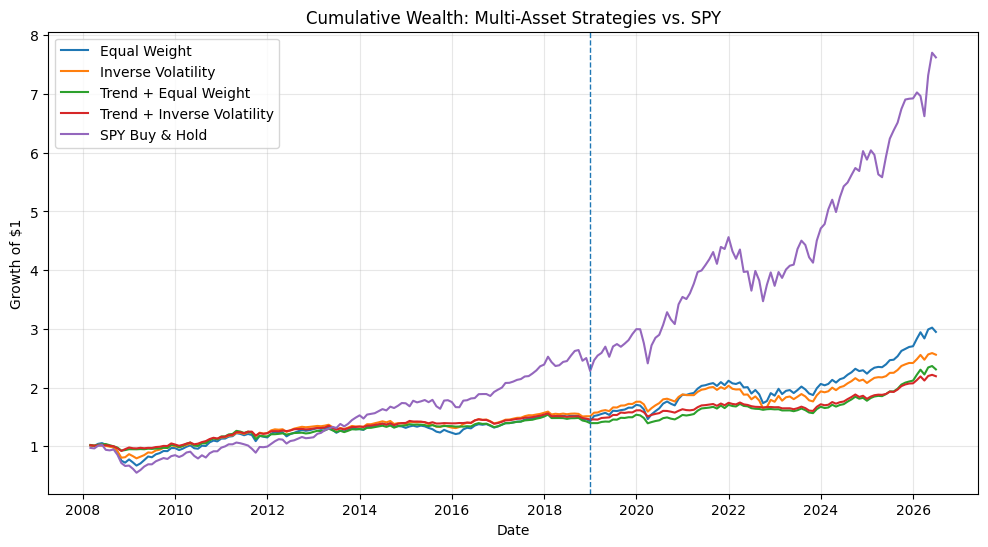

In [41]:
# ==========================================
# Step 40: Cumulative Wealth Curves
# ==========================================

plot_returns = strategy_net_returns.dropna(how="all").copy()

wealth_curves = (
    1.0 + plot_returns
).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))

for strategy in wealth_curves.columns:
    ax.plot(
        wealth_curves.index,
        wealth_curves[strategy],
        label=strategy,
        linewidth=1.5
    )

ax.axvline(
    pd.Timestamp(OOS_START),
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Cumulative Wealth: Multi-Asset Strategies vs. SPY"
)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

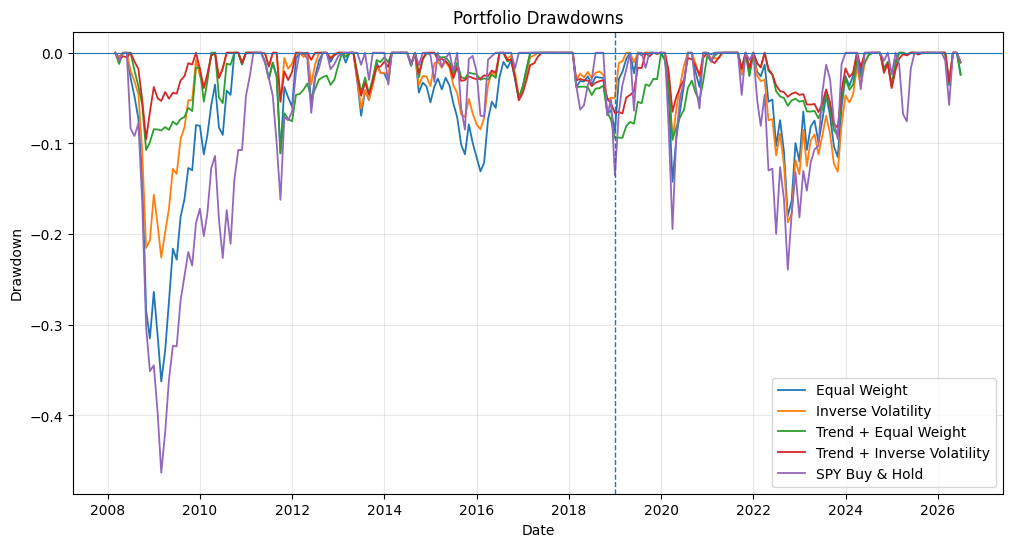

In [42]:
# ==========================================
# Step 41: Drawdown Curves
# ==========================================

running_max = wealth_curves.cummax()

drawdown_curves = (
    wealth_curves / running_max - 1.0
)

fig, ax = plt.subplots(figsize=(12, 6))

for strategy in drawdown_curves.columns:
    ax.plot(
        drawdown_curves.index,
        drawdown_curves[strategy],
        label=strategy,
        linewidth=1.3
    )

ax.axvline(
    pd.Timestamp(OOS_START),
    linestyle="--",
    linewidth=1
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_title(
    "Portfolio Drawdowns"
)
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

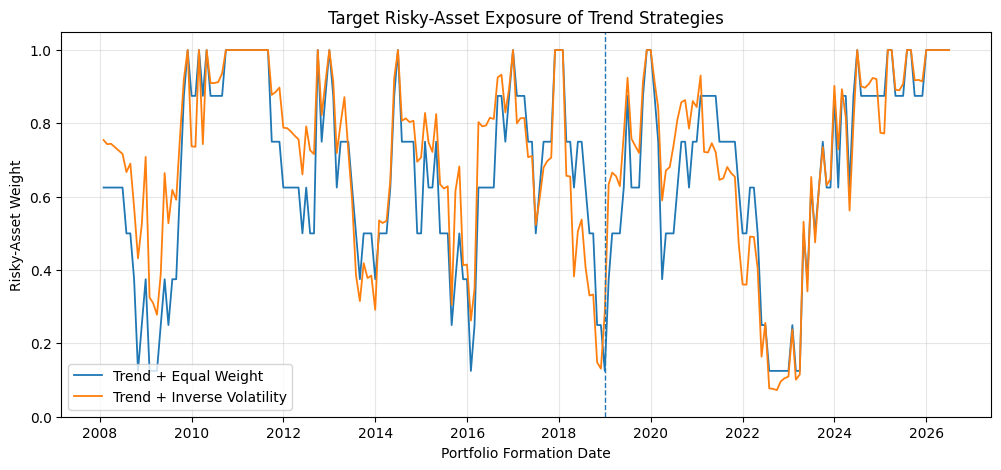

In [43]:
# ==========================================
# Step 42: Risky-Asset Exposure of Trend Strategies
# ==========================================

trend_exposure = pd.DataFrame({
    "Trend + Equal Weight": (
        trend_equal_weight.sum(
            axis=1,
            min_count=N_ASSETS
        )
    ),
    "Trend + Inverse Volatility": (
        trend_inverse_vol_weight.sum(
            axis=1,
            min_count=N_ASSETS
        )
    ),
})

trend_exposure = trend_exposure.loc[
    COMMON_FORMATION_START:
    COMMON_FORMATION_END
]

fig, ax = plt.subplots(figsize=(12, 5))

for strategy in trend_exposure.columns:
    ax.plot(
        trend_exposure.index,
        trend_exposure[strategy],
        label=strategy,
        linewidth=1.3
    )

ax.axvline(
    pd.Timestamp(OOS_START),
    linestyle="--",
    linewidth=1
)

ax.set_ylim(0, 1.05)

ax.set_title(
    "Target Risky-Asset Exposure of Trend Strategies"
)
ax.set_xlabel("Portfolio Formation Date")
ax.set_ylabel("Risky-Asset Weight")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

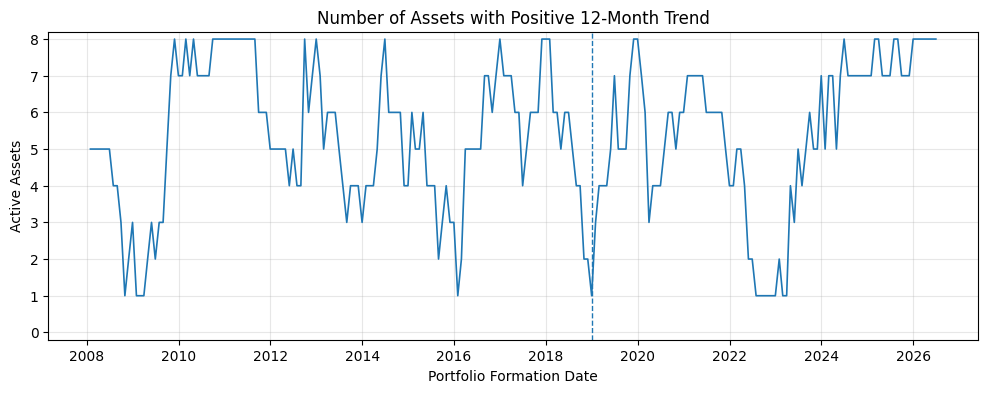

Active asset count summary:


,0
count,222.000000
mean,5.369369
std,2.010956
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,8.000000


In [44]:
# ==========================================
# Step 43: Number of Active Trend Assets
# ==========================================

active_asset_count_analysis = (
    trend_signal
    .loc[
        COMMON_FORMATION_START:
        COMMON_FORMATION_END
    ]
    .sum(axis=1)
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    active_asset_count_analysis.index,
    active_asset_count_analysis,
    linewidth=1.2
)

ax.axvline(
    pd.Timestamp(OOS_START),
    linestyle="--",
    linewidth=1
)

ax.set_ylim(-0.2, 8.2)
ax.set_title(
    "Number of Assets with Positive 12-Month Trend"
)
ax.set_xlabel("Portfolio Formation Date")
ax.set_ylabel("Active Assets")
ax.grid(alpha=0.3)

plt.show()

print("Active asset count summary:")
display(active_asset_count_analysis.describe())

## Visual Diagnostics Before Robustness Testing

The cumulative-wealth results show that SPY Buy & Hold generated substantially higher absolute wealth over the sample period. Therefore, the multi-asset strategies should not be interpreted as return-maximizing alternatives to US equity exposure.

The main observed benefit of the trend-filtered portfolios is instead downside-risk control. Their drawdowns are materially smaller than those of Equal Weight and SPY Buy & Hold.

The exposure diagnostics provide a plausible mechanical explanation. During several stressed periods, including the Global Financial Crisis, 2018–2019, and 2022–2023, fewer assets maintained positive 12-month trends and the trend portfolios consequently reduced risky-asset exposure and increased cash allocations.

Across the portfolio-formation sample, the mean number of assets with positive trends is approximately 5.37 out of 8, while the minimum is 1. This indicates that the strategy generally remains partially invested rather than switching completely into cash.

The exposure response is not instantaneous. A 12-month trend signal is inherently lagging and may therefore react slowly to abrupt market shocks such as the initial 2020 COVID-19 selloff.

These observations remain descriptive at this stage. Parameter and transaction-cost sensitivity tests are conducted next without changing the pre-specified primary specification.

In [45]:
# ==========================================
# Step 45-1: Trend Lookback Sensitivity
# ==========================================

TREND_LOOKBACK_GRID = [9, 12, 15]

sensitivity_signals = {}

for lookback in TREND_LOOKBACK_GRID:

    trailing_return = monthly_prices.pct_change(
        periods=lookback,
        fill_method=None
    )

    signal = (trailing_return > 0).astype(float)

    # Preserve NaN before sufficient history exists
    signal = signal.where(trailing_return.notna())

    sensitivity_signals[lookback] = signal

    first_valid = signal.dropna().index[0]

    print(
        f"{lookback}-month signal first valid date:",
        first_valid.date()
    )

9-month signal first valid date: 2007-10-31
12-month signal first valid date: 2008-01-31
15-month signal first valid date: 2008-04-30


In [46]:
# ==========================================
# Step 45-2: Common Sensitivity Formation Sample
# ==========================================

sensitivity_first_dates = []

for lookback, signal in sensitivity_signals.items():

    valid_mask = (
        signal.notna().all(axis=1)
        & inverse_vol_weight.notna().all(axis=1)
    )

    first_valid_date = signal.index[valid_mask][0]

    sensitivity_first_dates.append(first_valid_date)

    print(
        f"{lookback}-month first fully valid date:",
        first_valid_date.date()
    )

SENSITIVITY_FORMATION_START = max(sensitivity_first_dates)

SENSITIVITY_FORMATION_END = COMMON_FORMATION_END

sensitivity_index = monthly_prices.loc[
    SENSITIVITY_FORMATION_START:
    SENSITIVITY_FORMATION_END
].index

print("\n=== COMMON SENSITIVITY SAMPLE ===")
print("Start:", SENSITIVITY_FORMATION_START.date())
print("End:", SENSITIVITY_FORMATION_END.date())
print("Formation months:", len(sensitivity_index))

9-month first fully valid date: 2007-10-31
12-month first fully valid date: 2008-01-31
15-month first fully valid date: 2008-04-30

=== COMMON SENSITIVITY SAMPLE ===
Start: 2008-04-30
End: 2026-06-30
Formation months: 219


In [47]:
# ==========================================
# Step 45-3: Run Trend Lookback Sensitivity
# ==========================================

trend_sensitivity_backtests = {}

for lookback in TREND_LOOKBACK_GRID:

    signal = sensitivity_signals[lookback].reindex(
        sensitivity_index
    )

    # --------------------------------------
    # Trend + Equal Weight
    # --------------------------------------

    tew_weights = (
        signal * (1.0 / N_ASSETS)
    )

    tew_cash = (
        1.0
        - tew_weights.sum(
            axis=1,
            min_count=N_ASSETS
        )
    ).clip(lower=0.0, upper=1.0)

    tew_result = run_monthly_backtest(
        target_weights=tew_weights,
        cash_weights=tew_cash,
        monthly_asset_returns=monthly_returns,
        transaction_cost=TRANSACTION_COST
    )

    trend_sensitivity_backtests[
        (lookback, "Trend + Equal Weight")
    ] = tew_result

    # --------------------------------------
    # Trend + Inverse Volatility
    # --------------------------------------

    base_inv_vol = inverse_vol_weight.reindex(
        sensitivity_index
    )

    tiv_weights = (
        signal * base_inv_vol
    )

    tiv_cash = (
        1.0
        - tiv_weights.sum(
            axis=1,
            min_count=N_ASSETS
        )
    ).clip(lower=0.0, upper=1.0)

    tiv_result = run_monthly_backtest(
        target_weights=tiv_weights,
        cash_weights=tiv_cash,
        monthly_asset_returns=monthly_returns,
        transaction_cost=TRANSACTION_COST
    )

    trend_sensitivity_backtests[
        (lookback, "Trend + Inverse Volatility")
    ] = tiv_result

print("All lookback sensitivity backtests completed.")

All lookback sensitivity backtests completed.


In [48]:
# ==========================================
# Step 45-4: OOS Trend Lookback Sensitivity
# ==========================================

lookback_rows = []

for (
    lookback,
    strategy_name
), result in trend_sensitivity_backtests.items():

    returns = result["net_return"].loc[
        OOS_START:
    ]

    metrics = calculate_performance_metrics(
        returns
    )

    lookback_rows.append({
        "Trend Lookback": lookback,
        "Strategy": strategy_name,
        "CAGR": metrics["CAGR"],
        "Annualized Volatility": metrics[
            "Annualized Volatility"
        ],
        "Sharpe Ratio": metrics["Sharpe Ratio"],
        "Maximum Drawdown": metrics[
            "Maximum Drawdown"
        ],
    })

lookback_sensitivity_table = (
    pd.DataFrame(lookback_rows)
    .sort_values(
        ["Strategy", "Trend Lookback"]
    )
)

print("=== OOS TREND LOOKBACK SENSITIVITY ===")

display(
    lookback_sensitivity_table.style.format({
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
    })
)

=== OOS TREND LOOKBACK SENSITIVITY ===


,Trend Lookback,Strategy,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,9,Trend + Equal Weight,7.24%,6.91%,1.049,-11.01%
2,12,Trend + Equal Weight,6.96%,6.88%,1.014,-9.52%
4,15,Trend + Equal Weight,6.58%,7.12%,0.933,-10.73%
1,9,Trend + Inverse Volatility,5.72%,5.62%,1.020,-7.31%
3,12,Trend + Inverse Volatility,5.62%,5.71%,0.987,-8.22%
5,15,Trend + Inverse Volatility,5.21%,5.79%,0.908,-9.43%


In [49]:
# ==========================================
# Step 45-5: OOS Sharpe Sensitivity Matrix
# ==========================================

sharpe_sensitivity = (
    lookback_sensitivity_table
    .pivot(
        index="Trend Lookback",
        columns="Strategy",
        values="Sharpe Ratio"
    )
)

print("=== OOS SHARPE BY TREND LOOKBACK ===")
display(
    sharpe_sensitivity.style.format("{:.3f}")
)

=== OOS SHARPE BY TREND LOOKBACK ===


Strategy,Trend + Equal Weight,Trend + Inverse Volatility
Trend Lookback,,
9,1.049,1.020
12,1.014,0.987
15,0.933,0.908


In [50]:
# ==========================================
# Step 46-1: Transaction Cost Sensitivity
# ==========================================

COST_GRID = {
    "5 bps": 0.0005,
    "10 bps": 0.0010,
    "25 bps": 0.0025,
}

cost_sensitivity_rows = []

for strategy_name, result in backtests.items():

    gross_return = result["gross_return"]

    applied_turnover = (
        result["turnover"].shift(1)
    )

    for cost_name, cost_rate in COST_GRID.items():

        alternative_net_return = (
            gross_return
            - applied_turnover * cost_rate
        )

        oos_alt_return = alternative_net_return.loc[
            OOS_START:
        ]

        metrics = calculate_performance_metrics(
            oos_alt_return
        )

        cost_sensitivity_rows.append({
            "Strategy": strategy_name,
            "Transaction Cost": cost_name,
            "Cost Rate": cost_rate,
            "OOS CAGR": metrics["CAGR"],
            "OOS Sharpe": metrics["Sharpe Ratio"],
            "OOS Maximum Drawdown": metrics[
                "Maximum Drawdown"
            ],
        })

cost_sensitivity_table = (
    pd.DataFrame(cost_sensitivity_rows)
)

print("=== OOS TRANSACTION COST SENSITIVITY ===")

display(
    cost_sensitivity_table[
        [
            "Strategy",
            "Transaction Cost",
            "OOS CAGR",
            "OOS Sharpe",
            "OOS Maximum Drawdown",
        ]
    ].style.format({
        "OOS CAGR": "{:.2%}",
        "OOS Sharpe": "{:.3f}",
        "OOS Maximum Drawdown": "{:.2%}",
    })
)

=== OOS TRANSACTION COST SENSITIVITY ===


,Strategy,Transaction Cost,OOS CAGR,OOS Sharpe,OOS Maximum Drawdown
0,Equal Weight,5 bps,10.18%,0.938,-18.00%
1,Equal Weight,10 bps,10.17%,0.937,-18.01%
2,Equal Weight,25 bps,10.12%,0.933,-18.04%
3,Inverse Volatility,5 bps,7.33%,0.817,-18.69%
4,Inverse Volatility,10 bps,7.28%,0.812,-18.71%
5,Inverse Volatility,25 bps,7.13%,0.797,-18.79%
6,Trend + Equal Weight,5 bps,7.03%,1.024,-9.50%
7,Trend + Equal Weight,10 bps,6.96%,1.014,-9.52%
8,Trend + Equal Weight,25 bps,6.74%,0.985,-9.56%
9,Trend + Inverse Volatility,5 bps,5.71%,1.002,-8.09%


In [51]:
# ==========================================
# Step 46-2: OOS Sharpe by Transaction Cost
# ==========================================

cost_sharpe_matrix = (
    cost_sensitivity_table
    .pivot(
        index="Transaction Cost",
        columns="Strategy",
        values="OOS Sharpe"
    )
    .reindex(
        ["5 bps", "10 bps", "25 bps"]
    )
)

print("=== OOS SHARPE BY TRANSACTION COST ===")

display(
    cost_sharpe_matrix.style.format("{:.3f}")
)

=== OOS SHARPE BY TRANSACTION COST ===


Strategy,Equal Weight,Inverse Volatility,Trend + Equal Weight,Trend + Inverse Volatility
Transaction Cost,,,,
5 bps,0.938,0.817,1.024,1.002
10 bps,0.937,0.812,1.014,0.987
25 bps,0.933,0.797,0.985,0.940


## Robustness Results

The primary 12-month trend specification is not uniquely responsible for the observed OOS results.

Across nearby trend lookbacks of 9, 12, and 15 months, both trend-filtered portfolios maintain broadly similar risk-adjusted performance.

For Trend + Equal Weight, OOS Sharpe ratios are:

- 9 months: 1.049
- 12 months: 1.014
- 15 months: 0.933

For Trend + Inverse Volatility, OOS Sharpe ratios are:

- 9 months: 1.020
- 12 months: 0.987
- 15 months: 0.908

The pre-specified 12-month parameter is therefore not the ex-post best-performing specification. The nearby 9-month specification performs slightly better, while the 15-month specification performs somewhat worse but preserves the same broad direction of results.

Transaction-cost sensitivity is also limited within the tested range.

At 25 bps per unit of turnover, OOS Sharpe remains 0.985 for Trend + Equal Weight and 0.940 for Trend + Inverse Volatility.

Therefore, the primary conclusions do not depend on either a narrowly selected trend lookback or the base-case 10 bps transaction-cost assumption.

These tests support parameter and implementation-cost robustness, but they do not establish statistical significance or guarantee future profitability.

## Bias and Methodology Audit

### 1. Look-Ahead Bias

Portfolio signals and volatility estimates use only information available at the portfolio formation date.

Target weights formed at month-end t are applied only to returns earned during month t+1.

No future prices, returns, volatility estimates, or signals are used in portfolio formation.

### 2. Parameter Selection and Data Snooping

The primary Phase 0 specification was fixed before examining strategy performance:

- 8-ETF universe
- 12-month trend signal
- 63-trading-day realized volatility
- Monthly rebalancing
- 10 bps transaction cost
- 2019-01-01 OOS start date
- 0% cash return

Nearby 9-month and 15-month trend lookbacks are used only as sensitivity tests.

The primary 12-month specification is not replaced even though the 9-month specification produces slightly higher OOS performance.

### 3. In-Sample / Out-of-Sample Separation

Strategy performance is evaluated separately before and after 2019-01-01.

The OOS period is not used to redesign the primary strategy after observing results.

The OOS analysis therefore provides a stricter generalization check than full-sample performance alone.

### 4. Survivorship and Universe-Selection Bias

The ETF universe consists of eight liquid ETFs that are known to exist today and were selected retrospectively to represent major asset classes.

All eight ETFs have price histories covering the selected analysis period, but this does not fully eliminate survivorship or universe-selection bias.

The results should therefore be interpreted as evidence for the specified ETF universe rather than as an unbiased estimate for all historically investable multi-asset universes.

### 5. Missing-Data Treatment

Six isolated missing price observations are present in July 2026.

Rather than imputing unobserved prices, the primary analysis ends on 2026-06-30, the final complete month before those missing observations.

This cutoff was selected for data-quality reasons before examining strategy performance.

### 6. Transaction Costs

Transaction costs are modeled as a constant basis-point charge on risky-asset turnover.

The base case assumes 10 bps, with additional sensitivity tests at 5 and 25 bps.

The model does not explicitly include time-varying bid-ask spreads, market impact, taxes, broker-specific fees, or execution slippage.

### 7. Portfolio Rebalancing

Portfolio turnover is measured relative to pre-rebalance weights after allowing existing holdings to drift with realized returns.

This avoids overstating or understating trading needs by simply differencing consecutive target weights.

### 8. Cash and Financing

Inactive allocations in trend strategies are held in cash.

Cash earns 0% in Phase 0.

The portfolios use no leverage and no explicit financing costs.

## Limitations

1. **ETF proxies rather than institutional instruments**

   The analysis uses liquid ETFs as accessible proxies for major asset classes. Institutional systematic portfolios may instead use futures, swaps, or total-return indices with different financing, liquidity, roll, and execution characteristics.

2. **Retrospectively selected universe**

   The eight ETFs provide continuous histories across the study period, but the universe is selected with knowledge of assets available today. Survivorship and universe-selection bias are therefore not fully eliminated.

3. **Simplified transaction-cost model**

   A constant basis-point assumption does not capture time-varying spreads, market impact, taxes, execution delay, or liquidity differences across ETFs.

4. **Zero-return cash assumption**

   Cash earns 0% throughout Phase 0. This is intentionally conservative in periods of positive short-term interest rates but does not represent an actual cash or Treasury-bill return series.

5. **Lagging trend signal**

   The 12-month trend signal reacts gradually to changing market conditions. It can reduce exposure during prolonged declines but may respond slowly to abrupt market shocks.

6. **No leverage or explicit portfolio-volatility target**

   Inverse-volatility sizing changes relative allocations but does not target a constant total portfolio volatility. Therefore, lower-risk strategies may generate lower absolute returns partly because they maintain lower overall risk exposure.

7. **Limited parameter search**

   Only nearby 9-, 12-, and 15-month trend lookbacks are tested. This intentionally limits data snooping but does not characterize the full parameter space.

8. **No formal statistical inference**

   Phase 0 focuses on economic and implementation robustness. Confidence intervals, bootstrap inference, multiple-testing corrections, and formal statistical significance tests are not included.

9. **Historical backtest only**

   OOS historical performance is not equivalent to a live trading record. Structural market changes may weaken or eliminate historical relationships.

In [52]:
# ==========================================
# Step 50: Build Final OOS Summary Table
# ==========================================

final_summary = oos_performance[
    [
        "CAGR",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Calmar Ratio",
    ]
].copy()

# Add turnover for the four systematic portfolios
final_summary["Annualized Turnover"] = np.nan

for strategy in turnover_table.index:
    final_summary.loc[
        strategy,
        "Annualized Turnover"
    ] = turnover_table.loc[
        strategy,
        "Annualized Turnover"
    ]

print("=== PHASE 0 FINAL OOS SUMMARY ===")

display(
    final_summary.style.format({
        "CAGR": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}",
        "Calmar Ratio": "{:.3f}",
        "Annualized Turnover": "{:.2%}",
    })
)

=== PHASE 0 FINAL OOS SUMMARY ===


,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Annualized Turnover
Strategy,,,,,,
Equal Weight,10.17%,11.02%,0.937,-18.01%,0.564,31.33%
Inverse Volatility,7.28%,9.19%,0.812,-18.71%,0.389,92.90%
Trend + Equal Weight,6.96%,6.88%,1.014,-9.52%,0.731,135.86%
Trend + Inverse Volatility,5.62%,5.71%,0.987,-8.22%,0.683,173.97%
SPY Buy & Hold,17.45%,16.62%,1.056,-23.93%,0.729,nan%


In [53]:
# ==========================================
# Step 51: OOS Ablation Summary
# ==========================================

ablation_summary = pd.DataFrame({
    "OOS Sharpe": {
        "Equal Weight": oos_performance.loc[
            "Equal Weight", "Sharpe Ratio"
        ],
        "Inverse Volatility": oos_performance.loc[
            "Inverse Volatility", "Sharpe Ratio"
        ],
        "Trend + Equal Weight": oos_performance.loc[
            "Trend + Equal Weight", "Sharpe Ratio"
        ],
        "Trend + Inverse Volatility": oos_performance.loc[
            "Trend + Inverse Volatility", "Sharpe Ratio"
        ],
    },

    "OOS Maximum Drawdown": {
        "Equal Weight": oos_performance.loc[
            "Equal Weight", "Maximum Drawdown"
        ],
        "Inverse Volatility": oos_performance.loc[
            "Inverse Volatility", "Maximum Drawdown"
        ],
        "Trend + Equal Weight": oos_performance.loc[
            "Trend + Equal Weight", "Maximum Drawdown"
        ],
        "Trend + Inverse Volatility": oos_performance.loc[
            "Trend + Inverse Volatility", "Maximum Drawdown"
        ],
    },
})

print("=== OOS ABLATION SUMMARY ===")

display(
    ablation_summary.style.format({
        "OOS Sharpe": "{:.3f}",
        "OOS Maximum Drawdown": "{:.2%}",
    })
)

=== OOS ABLATION SUMMARY ===


,OOS Sharpe,OOS Maximum Drawdown
Equal Weight,0.937,-18.01%
Inverse Volatility,0.812,-18.71%
Trend + Equal Weight,1.014,-9.52%
Trend + Inverse Volatility,0.987,-8.22%


## Phase 0 Final Conclusion

The Phase 0 results provide partial support for the primary hypothesis.

The 12-month trend filter improves the out-of-sample risk profile of the diversified multi-asset portfolio relative to static equal-weight allocation.

From January 2019 through June 2026:

- Equal Weight achieves a Sharpe ratio of 0.937 with a maximum drawdown of -18.01%.
- Trend + Equal Weight achieves a Sharpe ratio of 1.014 with a maximum drawdown of -9.52%.
- Trend + Inverse Volatility achieves a Sharpe ratio of 0.987 with a maximum drawdown of -8.22%.
- Inverse Volatility alone achieves a Sharpe ratio of 0.812 with a maximum drawdown of -18.71%.

The ablation results suggest that the trend filter is the primary contributor to the observed improvement in downside-risk control and OOS risk-adjusted performance.

Inverse-volatility sizing alone does not improve OOS Sharpe relative to Equal Weight. Adding inverse-volatility sizing to the trend strategy further reduces realized volatility and maximum drawdown, but it also lowers CAGR and Sharpe relative to Trend + Equal Weight.

Therefore, the data do not support the stronger claim that inverse-volatility sizing provides incremental OOS risk-adjusted performance beyond the trend filter. Its observed contribution is primarily additional risk reduction.

The trend results are reasonably stable across nearby 9-, 12-, and 15-month lookbacks. The pre-specified 12-month specification is not the ex-post best-performing parameter, reducing concern that the primary result is driven by a narrowly selected historical optimum.

The conclusions are also relatively stable under transaction-cost assumptions ranging from 5 to 25 basis points per unit of turnover.

SPY Buy & Hold remains an important benchmark. It generates materially higher absolute returns and a slightly higher OOS Sharpe ratio than the multi-asset strategies, but with substantially larger volatility and drawdown. Therefore, this project does not provide evidence that the systematic multi-asset strategies outperform US equities on an absolute-return basis.

Overall, the Phase 0 evidence is most consistent with the following interpretation:

> A simple medium-term trend filter can materially reduce downside exposure in a diversified multi-asset ETF portfolio, while inverse-volatility sizing provides additional risk reduction but does not independently improve OOS risk-adjusted performance in this sample.

These findings should be interpreted as historical backtest evidence rather than proof of persistent alpha or future profitability.

## Interpretation Boundaries

### What the Phase 0 Results Support

The results support the following statements:

- A pre-specified 12-month trend filter reduced OOS maximum drawdown relative to static equal-weight allocation in the selected multi-asset ETF universe.
- Both trend-filtered portfolios achieved higher OOS Sharpe ratios than Equal Weight under the base-case transaction-cost assumption.
- The trend effect remained broadly similar under nearby 9-, 12-, and 15-month lookbacks.
- The main conclusions remained stable when transaction costs were increased from 10 bps to 25 bps.
- Inverse-volatility sizing materially reduced portfolio volatility.
- Combining trend filtering and inverse-volatility sizing produced the lowest OOS maximum drawdown among the four systematic portfolios.
- The ablation analysis indicates that the trend filter contributed more to the observed OOS Sharpe improvement than inverse-volatility sizing.

### What the Phase 0 Results Do Not Support

The results do not establish that:

- The strategies generate persistent alpha.
- The strategies will remain profitable in future markets.
- The strategies outperform SPY Buy & Hold on an absolute-return basis.
- The 12-month trend parameter is optimal.
- Inverse-volatility sizing independently improves OOS Sharpe.
- The results are statistically significant.
- Survivorship and universe-selection bias have been fully eliminated.
- ETF backtest performance directly represents institutional futures or derivatives implementation.
- The simplified transaction-cost assumptions capture all real-world execution frictions.

Phase 0 should therefore be interpreted as a disciplined systematic-research exercise rather than as evidence of a production-ready trading strategy.

In [54]:
# ==========================================
# Step 54: Export Phase 0 Result Tables
# ==========================================

import os

OUTPUT_DIR = "phase0_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Final OOS performance summary
final_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_oos_summary.csv"
    )
)

# OOS ablation summary
ablation_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_ablation_summary.csv"
    )
)

# Trend lookback sensitivity
lookback_sensitivity_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_trend_lookback_sensitivity.csv"
    ),
    index=False
)

# Transaction-cost sensitivity
cost_sensitivity_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_transaction_cost_sensitivity.csv"
    ),
    index=False
)

# Turnover summary
turnover_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase0_turnover_summary.csv"
    )
)

print("=== EXPORTED FILES ===")

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

=== EXPORTED FILES ===
phase0_ablation_summary.csv
phase0_oos_summary.csv
phase0_transaction_cost_sensitivity.csv
phase0_trend_lookback_sensitivity.csv
phase0_turnover_summary.csv
